In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

# 1: Nạp data

In [2]:
try:
    df = pd.read_csv('50_sample_data.csv')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('50_sample_data.csv', encoding='latin1')
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        exit()

df.columns = df.columns.str.strip()

print("--- Thông tin cơ bản về dữ liệu ---")
df.info()

--- Thông tin cơ bản về dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       101 non-null    int64  
 1   Restaurant name                                     101 non-null    object 
 2   Subzone                                             101 non-null    object 
 3   City                                                101 non-null    object 
 4   Order ID                                            101 non-null    int64  
 5   Order Placed At                                     101 non-null    object 
 6   Order Status                                        101 non-null    object 
 7   Delivery                                            101 non-null    object 
 8   Distance                                    

In [3]:
print("\n--- 5 dòng dữ liệu đầu tiên ---")
print(df.head())


--- 5 dòng dữ liệu đầu tiên ---
   Restaurant ID Restaurant name   Subzone       City    Order ID  \
0       20320607           Swaad  Sector 4  Delhi NCR  6168884918   
1       20320607           Swaad  Sector 4  Delhi NCR  6170707559   
2       20320607           Swaad  Sector 4  Delhi NCR  6169375019   
3       20320607           Swaad  Sector 4  Delhi NCR  6151677434   
4       20320607           Swaad  Sector 4  Delhi NCR  6167540897   

       Order Placed At Order Status         Delivery  Distance  \
0  2024-09-10 23:38:00    Delivered  Zomato Delivery       3.0   
1  2024-09-10 23:34:00    Delivered  Zomato Delivery       2.0   
2  2024-09-10 15:52:00    Delivered  Zomato Delivery       0.5   
3  2024-09-10 15:45:00    Delivered  Zomato Delivery       2.0   
4  2024-09-10 15:04:00    Delivered  Zomato Delivery       2.0   

                                      Items in order  ... Brand pack discount  \
0  1 x Grilled Chicken Jamaican Tender, 1 x Grill...  ...                 

## 1.1 Thống kê mô tả cho các cột số

In [4]:
print("\n--- Thống kê mô tả cho các cột số ---")
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe())


--- Thống kê mô tả cho các cột số ---
       Restaurant ID      Order ID    Distance  Bill subtotal  \
count   1.010000e+02  1.010000e+02  101.000000     101.000000   
mean    2.047971e+07  6.155488e+09    3.668317     598.763366   
std     1.583240e+05  5.848025e+06    1.914781     311.825627   
min     2.032061e+07  6.134676e+09    0.500000     189.000000   
25%     2.032061e+07  6.152693e+09    2.000000     355.000000   
50%     2.063570e+07  6.155785e+09    3.000000     584.000000   
75%     2.063570e+07  6.157713e+09    5.000000     698.000000   
max     2.063570e+07  6.170708e+09   10.000000    2326.000000   

       Packaging charges  Restaurant discount (Promo)  \
count         101.000000                   101.000000   
mean           26.928515                    54.402178   
std            15.573032                    54.693924   
min             4.740000                     0.000000   
25%            16.250000                     0.000000   
50%            26.750000         

## 1.2 Kiểm tra Missing Values

In [5]:
print("\n--- Kiểm tra giá trị thiếu (Missing Values) ---")
print(df.isnull().sum())


--- Kiểm tra giá trị thiếu (Missing Values) ---
Restaurant ID                                           0
Restaurant name                                         0
Subzone                                                 0
City                                                    0
Order ID                                                0
Order Placed At                                         0
Order Status                                            0
Delivery                                                0
Distance                                                0
Items in order                                          0
Discount construct                                      3
Bill subtotal                                           0
Packaging charges                                       0
Restaurant discount (Promo)                             0
Restaurant discount (Flat offs, Freebies & others)      0
Gold discount                                           0
Brand pack discount    

# 2: Tiền xử lý dữ liệu

In [6]:
# Tạm thời điền giá trị số thiếu bằng median (Ở các cột: Rating, KPT, Rider wait time)
for col in ['Rating', 'KPT duration (minutes)', 'Rider wait time (minutes)']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median()) # Hoặc mean()

# cột 'Discount construct' (NaN) thay bằng 'No Discount'
df['Discount construct'] = df['Discount construct'].fillna('No Discount')

# Chuẩn hóa các loại % off
def clean_discount(text):
    if isinstance(text, str):
        if '%' in text and 'off upto' in text:
            return 'Percentage Off with Cap'
        elif 'Flat' in text and 'off' in text:
            return 'Flat Off'
        elif text == 'No Discount':
            return 'No Discount'
        elif 'Buy' in text and 'Get' in text:
            return 'Buy X Get Y'
    return 'Other/Unknown'

df['Discount Category'] = df['Discount construct'].apply(clean_discount)
print("\n--- Các loại Discount Category sau khi gom nhóm ---")
print(df['Discount Category'].value_counts())


--- Các loại Discount Category sau khi gom nhóm ---
Discount Category
Buy X Get Y                43
Percentage Off with Cap    40
Flat Off                   15
No Discount                 3
Name: count, dtype: int64


# 3: Visualize data

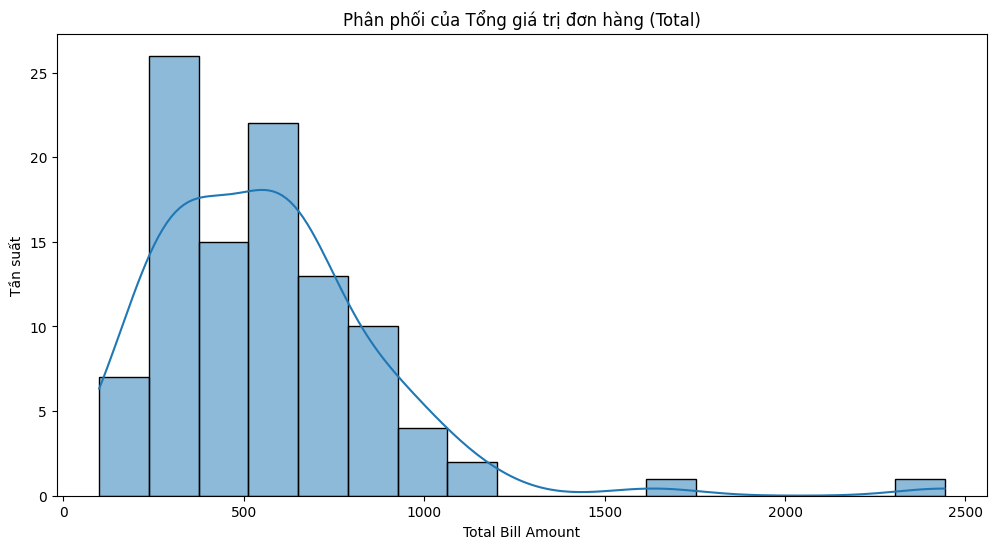

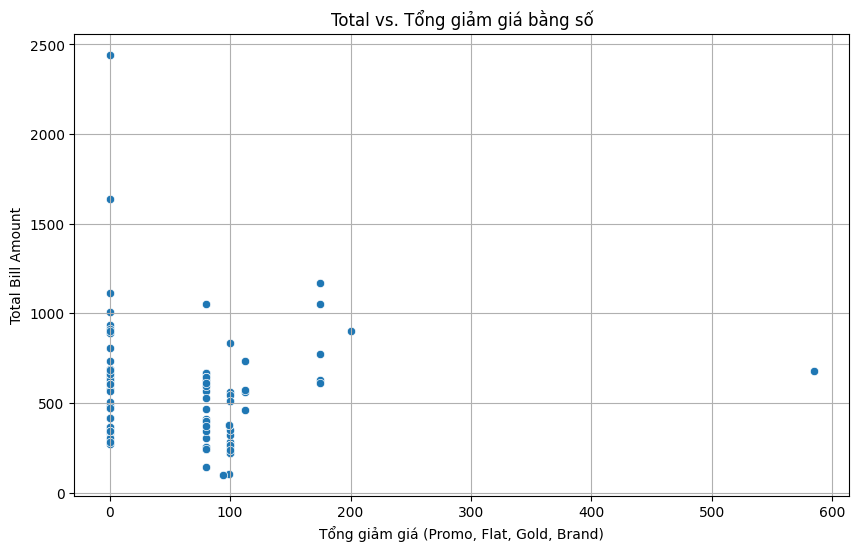

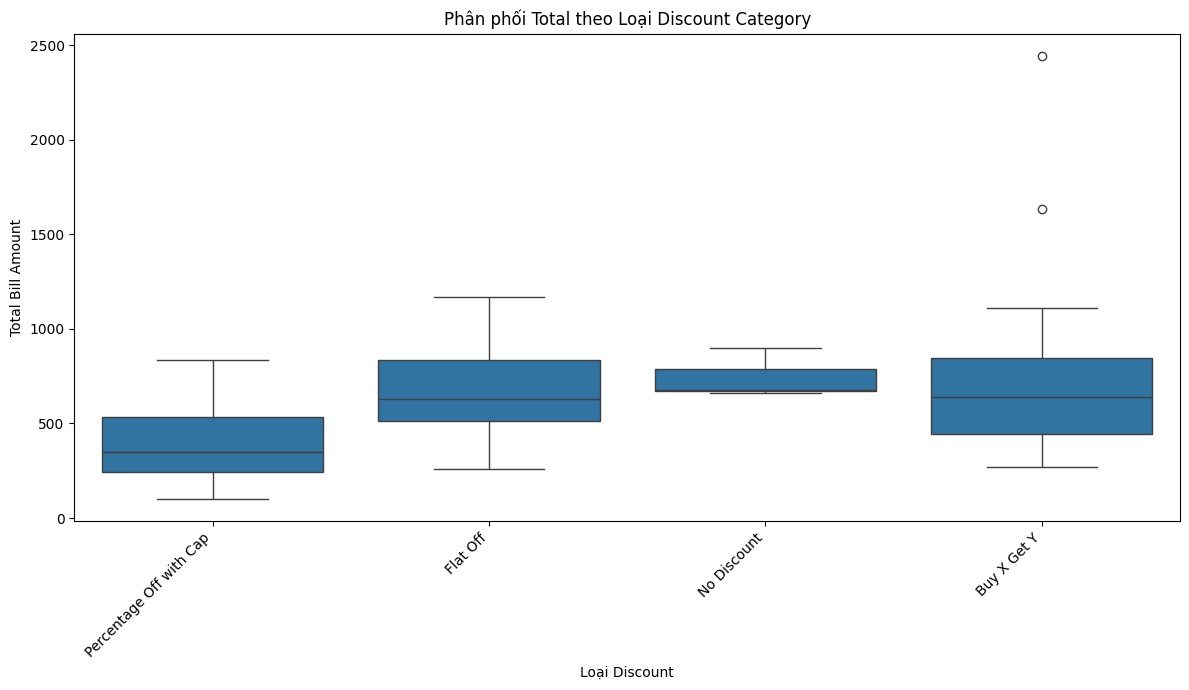

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Total'], kde=True)
plt.title('Phân phối của Tổng giá trị đơn hàng (Total)')
plt.xlabel('Total Bill Amount')
plt.ylabel('Tần suất')
plt.show()

# Mối quan hệ giữa các loại giảm giá số và Total
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]

df['Total Numerical Discount'] = df[discount_cols_numeric].sum(axis=1)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Numerical Discount', y='Total', data=df)
plt.title('Total vs. Tổng giảm giá bằng số')
plt.xlabel('Tổng giảm giá (Promo, Flat, Gold, Brand)')
plt.ylabel('Total Bill Amount')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(x='Discount Category', y='Total', data=df)
plt.title('Phân phối Total theo Loại Discount Category')
plt.xlabel('Loại Discount')
plt.ylabel('Total Bill Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4: Phân tích ANOVA
- Xem xét liệu có sự khác biệt đáng kể về mặt thống kê trong giá trị trung bình của 'Total' giữa các nhóm 'Discount Category' khác nhau hay không


--- Trực quan hóa Phân phối 'Total' theo 'Discount Category' (Hỗ trợ ANOVA) ---


<ipython-input-26-bedc111e614e>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount Category', y='Total', data=df_anova, palette='Set2', showfliers=True) # showfliers để hiện điểm ngoại lệ


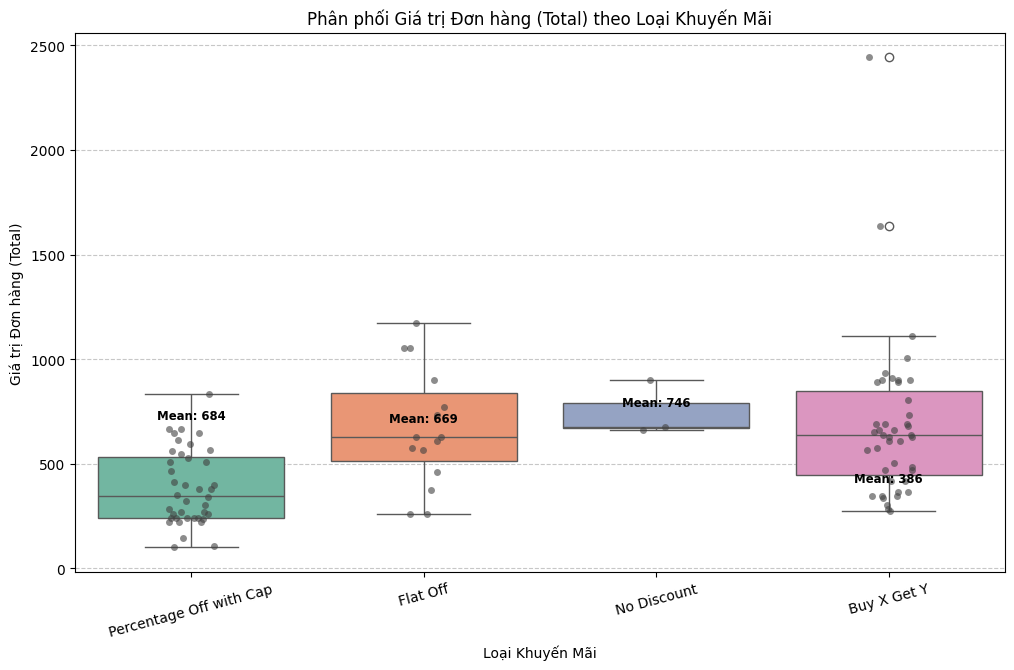


Giải thích biểu đồ Box Plot:
- Biểu đồ này trực quan hóa sự phân phối của giá trị 'Total' cho từng loại khuyến mãi.
- Mỗi 'hộp' thể hiện: đường giữa là trung vị (median), đáy và đỉnh hộp là tứ phân vị thứ 1 (Q1) và thứ 3 (Q3), 'râu' kéo dài đến giá trị không phải ngoại lệ, các chấm là điểm ngoại lệ.
- Giá trị 'Mean' (trung bình) được ghi chú cho mỗi nhóm.
- Bằng cách so sánh vị trí và kích thước của các hộp, cũng như giá trị trung bình, bạn có thể thấy sự khác biệt về 'Total' giữa các nhóm Discount Category.
- Ví dụ: Nếu các hộp nằm ở các độ cao khác nhau đáng kể hoặc giá trị trung bình (Mean) khác xa nhau, điều đó củng cố kết quả ANOVA rằng có sự khác biệt giữa các nhóm.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Đảm bảo df và df_anova đã tồn tại từ các bước trước ---
# df_anova là DataFrame đã lọc các category có ít nhất 2 mẫu

print("\n--- Trực quan hóa Phân phối 'Total' theo 'Discount Category' (Hỗ trợ ANOVA) ---")

plt.figure(figsize=(12, 7))

# Sử dụng Box Plot để so sánh phân phối giữa các nhóm
sns.boxplot(x='Discount Category', y='Total', data=df_anova, palette='Set2', showfliers=True) # showfliers để hiện điểm ngoại lệ

# (Tùy chọn) Thêm stripplot để thấy các điểm dữ liệu riêng lẻ
sns.stripplot(x='Discount Category', y='Total', data=df_anova, color=".25", alpha=0.6)

# Tính toán và đánh dấu giá trị trung bình cho mỗi nhóm
means = df_anova.groupby('Discount Category')['Total'].mean()
vertical_offset = df_anova['Total'].median() * 0.05 # Offset nhỏ để chữ không đè lên box

for i, cat in enumerate(means.index):
    plt.text(i, means[cat] + vertical_offset, f'Mean: {means[cat]:.0f}',
             horizontalalignment='center', size='small', color='black', weight='semibold')


plt.title('Phân phối Giá trị Đơn hàng (Total) theo Loại Khuyến Mãi')
plt.xlabel('Loại Khuyến Mãi')
plt.ylabel('Giá trị Đơn hàng (Total)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nGiải thích biểu đồ Box Plot:")
print("- Biểu đồ này trực quan hóa sự phân phối của giá trị 'Total' cho từng loại khuyến mãi.")
print("- Mỗi 'hộp' thể hiện: đường giữa là trung vị (median), đáy và đỉnh hộp là tứ phân vị thứ 1 (Q1) và thứ 3 (Q3), 'râu' kéo dài đến giá trị không phải ngoại lệ, các chấm là điểm ngoại lệ.")
print("- Giá trị 'Mean' (trung bình) được ghi chú cho mỗi nhóm.")
print("- Bằng cách so sánh vị trí và kích thước của các hộp, cũng như giá trị trung bình, bạn có thể thấy sự khác biệt về 'Total' giữa các nhóm Discount Category.")
print("- Ví dụ: Nếu các hộp nằm ở các độ cao khác nhau đáng kể hoặc giá trị trung bình (Mean) khác xa nhau, điều đó củng cố kết quả ANOVA rằng có sự khác biệt giữa các nhóm.")

# => Do dữ liệu không phải là chuỗi thời gian, không áp dụng khái niệm 'stationary'

# 5: Xây dựng mô hình để dự đoán ảnh hưởng của các loại khuyến mãi lên Bill-subtotal



In [9]:
# Dùng giảm giá số + các chi phí khác
features = df[discount_cols_numeric + ['Packaging charges', 'Bill subtotal']]

if 'Total Numerical Discount' in features.columns:
    features = features.drop(columns=['Total Numerical Discount'])

target = df['Total']

# Định nghĩa số folds cho cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

## 5.1 Linear Regression

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Đảm bảo đã import

# --- Đảm bảo df đã được tải và có cột 'Discount Category' ---
# Ví dụ tiền xử lý đã làm:
# df['Discount construct'] = df['Discount construct'].fillna('No Discount')
# def clean_discount(text): ...
# df['Discount Category'] = df['Discount construct'].apply(clean_discount)

# --- Định nghĩa lại Biến Mục tiêu và Đặc trưng ---
# Mục tiêu mới: Dự đoán giá trị ban đầu của giỏ hàng
new_target = df['Bill subtotal']

# Đặc trưng chính: Loại khuyến mãi (cần mã hóa)
# Các đặc trưng khác có thể xem xét (tùy chọn): Distance, Hour, DayOfWeek...
# TẠM THỜI CHỈ DÙNG Discount Category để tập trung vào tác động của loại KM
categorical_features = ['Discount Category']
# Các đặc trưng số khác (nếu muốn thêm vào sau):
# numerical_features = ['Distance'] # Ví dụ

# --- Mã hóa One-Hot cho Discount Category ---
# Sử dụng ColumnTransformer để xử lý đúng trong pipeline và cross-validation
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        # Thêm 'num' transformer nếu có numerical_features
        # ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Giữ lại các cột không được chỉ định (nếu có)
)

# --- Định nghĩa lại CV (giữ nguyên) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42) # Giảm K xuống 5 nếu 101 mẫu là hơi ít

# --- Định nghĩa lại Hàm Đánh giá (giữ nguyên) ---
def evaluate_model_cv(name, model_pipeline, X, y, cv):
    # Quan trọng: Bây giờ model là pipeline bao gồm cả tiền xử lý
    # X là DataFrame gốc trước khi mã hóa
    scores_rmse = np.sqrt(-cross_val_score(model_pipeline, X, y, scoring='neg_mean_squared_error', cv=cv, n_jobs=1))
    scores_mae = -cross_val_score(model_pipeline, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=1)
    scores_r2 = cross_val_score(model_pipeline, X, y, scoring='r2', cv=cv, n_jobs=1)

    print(f"--- Đánh giá mô hình (CV): {name} (Dự đoán Bill Subtotal) ---")
    print(f"RMSE: {np.mean(scores_rmse):.2f} (± {np.std(scores_rmse):.2f})")
    print(f"MAE:  {np.mean(scores_mae):.2f} (± {np.std(scores_mae):.2f})")
    print(f"R2:   {np.mean(scores_r2):.3f} (± {np.std(scores_r2):.3f})")
    print("---------------------------------------------------------")
    return np.mean(scores_rmse), np.mean(scores_mae), np.mean(scores_r2)

# --- Dữ liệu đầu vào cho mô hình (DataFrame gốc chứa cột cần mã hóa) ---
features_df = df[categorical_features].copy() # Chỉ lấy cột Discount Category
# Nếu muốn thêm 'Distance': features_df = df[categorical_features + numerical_features].copy()




--- 5.1: Linear Regression (Dự đoán Bill Subtotal dựa trên Loại Khuyến Mãi) ---
--- Đánh giá mô hình (CV): Linear Regression (Dự đoán Bill Subtotal) ---
RMSE: 289.19 (± 103.14)
MAE:  212.60 (± 47.40)
R2:   -0.088 (± 0.408)
---------------------------------------------------------

Hệ số Hồi quy Tuyến tính (Dự đoán Bill Subtotal):
                                          Feature  \
2              cat__Discount Category_No Discount   
1                 cat__Discount Category_Flat Off   
0              cat__Discount Category_Buy X Get Y   
3  cat__Discount Category_Percentage Off with Cap   

   Coefficient (Impact on Subtotal)  
2                            210.91  
1                             70.61  
0                            -43.40  
3                           -238.12  

Intercept (Giá trị Subtotal cơ sở/baseline): 694.79

--- Trực quan hóa Hệ số LR (Ảnh hưởng Loại KM lên Bill Subtotal) ---


<ipython-input-32-654800b7f12e>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient (Impact on Subtotal)', y='Feature', data=coef_subtotal_df, palette=colors_lr)


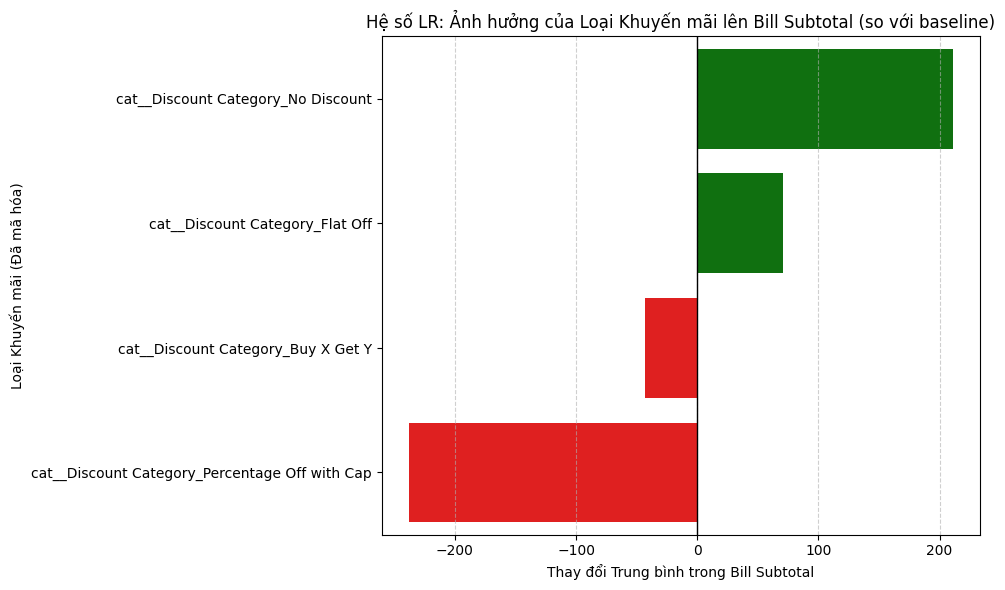


Giải thích biểu đồ hệ số (Dự đoán Bill Subtotal):
- Biểu đồ này cho thấy mỗi loại khuyến mãi (so với một nhóm cơ sở mà OneHotEncoder bỏ qua) làm thay đổi giá trị `Bill Subtotal` trung bình là bao nhiêu.
- Hệ số dương: Loại KM đó có liên quan đến `Bill Subtotal` trung bình cao hơn so với nhóm cơ sở.
- Hệ số âm: Loại KM đó có liên quan đến `Bill Subtotal` trung bình thấp hơn so với nhóm cơ sở.
- Intercept: Là giá trị `Bill Subtotal` trung bình dự kiến cho nhóm cơ sở (thường là category đầu tiên theo alphabet hoặc category bị drop bởi encoder).
- => Kết quả này giúp trả lời: Loại KM nào thường đi kèm với giỏ hàng giá trị cao/thấp hơn?

--- Trực quan hóa Dự đoán vs Thực tế (LR - Bill Subtotal) ---


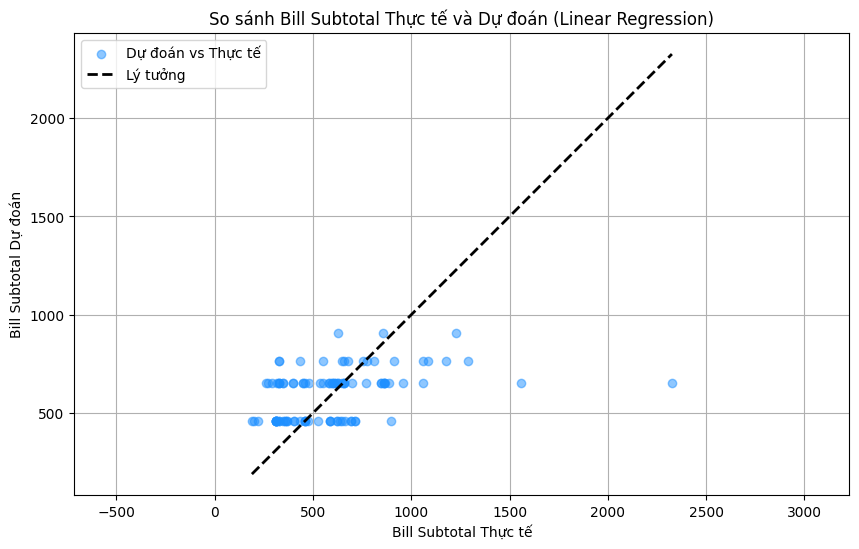


Giải thích biểu đồ dự đoán (Bill Subtotal):
- Biểu đồ so sánh Bill Subtotal thực tế với giá trị dự đoán chỉ dựa trên Loại Khuyến mãi.
- Độ chính xác sẽ THẤP hơn nhiều so với việc dự đoán Total, vì mối quan hệ giữa Loại KM và Subtotal không phải là công thức toán học mà phụ thuộc hành vi khách hàng.
- Sự phân tán của các điểm so với đường y=x cho thấy mức độ khó khăn của việc dự đoán Subtotal chỉ bằng loại KM.


In [32]:
print("\n--- 5.1: Linear Regression (Dự đoán Bill Subtotal dựa trên Loại Khuyến Mãi) ---")

# Tạo pipeline kết hợp tiền xử lý (OneHotEncoder) và mô hình Linear Regression
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])

# Đánh giá mô hình bằng cross-validation
lr_metrics_subtotal = evaluate_model_cv("Linear Regression", lr_pipeline, features_df, new_target, cv)

# Huấn luyện lại trên toàn bộ dữ liệu để xem hệ số
lr_pipeline.fit(features_df, new_target)

# Lấy tên các đặc trưng sau khi OneHotEncode
# Tên cột có thể khác tùy phiên bản sklearn, cần kiểm tra
try:
    encoded_feature_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out(categorical_features)
except AttributeError: # Cho phiên bản sklearn cũ hơn
     encoded_feature_names = lr_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names(categorical_features)


# Lấy hệ số và intercept
coefficients = lr_pipeline.named_steps['regressor'].coef_
intercept = lr_pipeline.named_steps['regressor'].intercept_

# Tạo DataFrame hệ số
coef_subtotal_df = pd.DataFrame({'Feature': encoded_feature_names, 'Coefficient (Impact on Subtotal)': coefficients})
# Sắp xếp để dễ nhìn
coef_subtotal_df = coef_subtotal_df.sort_values(by='Coefficient (Impact on Subtotal)', ascending=False)

print("\nHệ số Hồi quy Tuyến tính (Dự đoán Bill Subtotal):")
print(coef_subtotal_df)
print(f"\nIntercept (Giá trị Subtotal cơ sở/baseline): {intercept:.2f}")


# --- Trực quan hóa Hệ số ---
print("\n--- Trực quan hóa Hệ số LR (Ảnh hưởng Loại KM lên Bill Subtotal) ---")
plt.figure(figsize=(10, 6))
# Phân biệt màu
colors_lr = ['green' if x > 0 else 'red' if x < 0 else 'grey' for x in coef_subtotal_df['Coefficient (Impact on Subtotal)']]
sns.barplot(x='Coefficient (Impact on Subtotal)', y='Feature', data=coef_subtotal_df, palette=colors_lr)
plt.title('Hệ số LR: Ảnh hưởng của Loại Khuyến mãi lên Bill Subtotal (so với baseline)')
plt.xlabel('Thay đổi Trung bình trong Bill Subtotal')
plt.ylabel('Loại Khuyến mãi (Đã mã hóa)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(x=0, color='black', lw=1)
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ hệ số (Dự đoán Bill Subtotal):")
print("- Biểu đồ này cho thấy mỗi loại khuyến mãi (so với một nhóm cơ sở mà OneHotEncoder bỏ qua) làm thay đổi giá trị `Bill Subtotal` trung bình là bao nhiêu.")
print("- Hệ số dương: Loại KM đó có liên quan đến `Bill Subtotal` trung bình cao hơn so với nhóm cơ sở.")
print("- Hệ số âm: Loại KM đó có liên quan đến `Bill Subtotal` trung bình thấp hơn so với nhóm cơ sở.")
print("- Intercept: Là giá trị `Bill Subtotal` trung bình dự kiến cho nhóm cơ sở (thường là category đầu tiên theo alphabet hoặc category bị drop bởi encoder).")
print("- => Kết quả này giúp trả lời: Loại KM nào thường đi kèm với giỏ hàng giá trị cao/thấp hơn?")

# --- Trực quan hóa Dự đoán vs Thực tế (Bill Subtotal) ---
print("\n--- Trực quan hóa Dự đoán vs Thực tế (LR - Bill Subtotal) ---")
predictions_lr_subtotal = lr_pipeline.predict(features_df)

plt.figure(figsize=(10, 6))
plt.scatter(new_target, predictions_lr_subtotal, alpha=0.5, color='dodgerblue', label='Dự đoán vs Thực tế')
min_val = min(new_target.min(), predictions_lr_subtotal.min())
max_val = max(new_target.max(), predictions_lr_subtotal.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Lý tưởng')
plt.title('So sánh Bill Subtotal Thực tế và Dự đoán (Linear Regression)')
plt.xlabel('Bill Subtotal Thực tế')
plt.ylabel('Bill Subtotal Dự đoán')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()
print("\nGiải thích biểu đồ dự đoán (Bill Subtotal):")
print("- Biểu đồ so sánh Bill Subtotal thực tế với giá trị dự đoán chỉ dựa trên Loại Khuyến mãi.")
print("- Độ chính xác sẽ THẤP hơn nhiều so với việc dự đoán Total, vì mối quan hệ giữa Loại KM và Subtotal không phải là công thức toán học mà phụ thuộc hành vi khách hàng.")
print("- Sự phân tán của các điểm so với đường y=x cho thấy mức độ khó khăn của việc dự đoán Subtotal chỉ bằng loại KM.")

## 5.2 Random Forest Regressor


--- 5.2: Random Forest (Dự đoán Bill Subtotal dựa trên Loại Khuyến Mãi) ---
--- Đánh giá mô hình (CV): Random Forest (Dự đoán Bill Subtotal) ---
RMSE: 288.07 (± 103.74)
MAE:  211.54 (± 47.67)
R2:   -0.077 (± 0.397)
---------------------------------------------------------

Độ quan trọng của Biến (Random Forest - Dự đoán Bill Subtotal):
                                          Feature  Importance (for Subtotal)
3  cat__Discount Category_Percentage Off with Cap                       0.74
2              cat__Discount Category_No Discount                       0.11
0              cat__Discount Category_Buy X Get Y                       0.09
1                 cat__Discount Category_Flat Off                       0.07

--- Trực quan hóa Độ quan trọng RF (Ảnh hưởng Loại KM lên Bill Subtotal) ---


<ipython-input-33-805bc296c917>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (for Subtotal)', y='Feature', data=feature_importance_rf_subtotal, palette='magma')


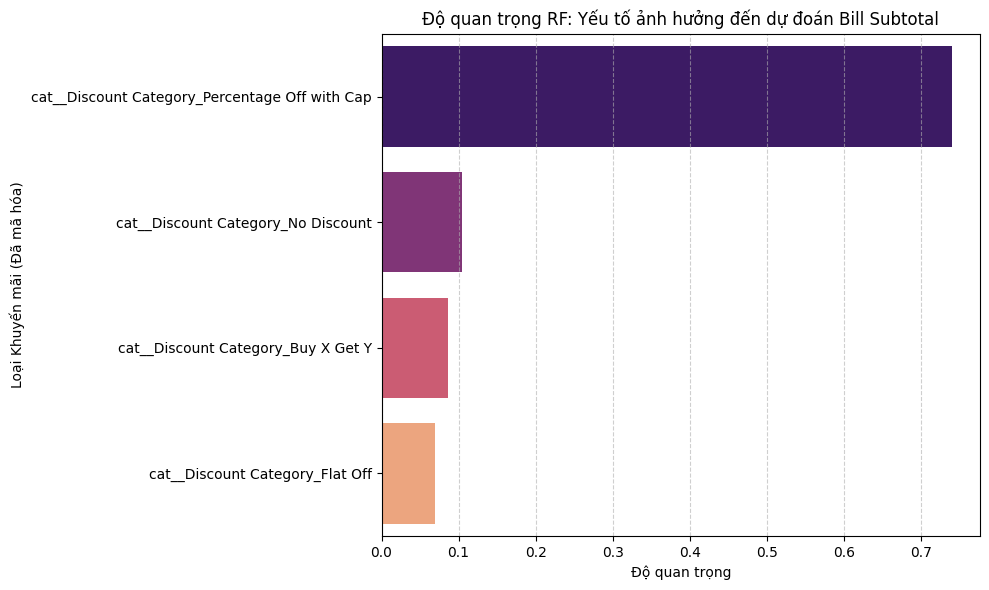


Giải thích biểu đồ Độ quan trọng (Dự đoán Bill Subtotal):
- Biểu đồ này cho thấy Random Forest coi loại khuyến mãi nào là quan trọng nhất khi dự đoán giá trị `Bill Subtotal`.
- Khác với LR, nó không chỉ ra chiều hướng (tăng/giảm), chỉ mức độ quan trọng trong việc ra quyết định của mô hình.
- Kết quả này có thể khác với hệ số LR, vì RF có thể nắm bắt các tương tác phức tạp hơn (nếu có).

--- Trực quan hóa Dự đoán vs Thực tế (RF - Bill Subtotal) ---


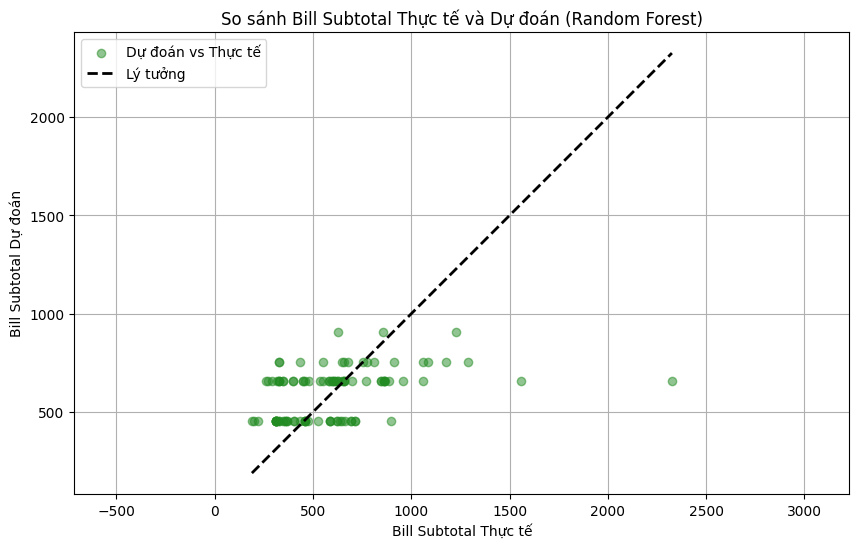


Giải thích biểu đồ dự đoán (Bill Subtotal):
- Biểu đồ so sánh Bill Subtotal thực tế với giá trị dự đoán bởi Random Forest (chỉ dựa trên Loại KM).
- Tương tự LR đã điều chỉnh, độ chính xác dự kiến sẽ thấp hơn nhiều so với mô hình dự đoán Total ban đầu.
- So sánh sự phân tán trên biểu đồ này với biểu đồ của LR có thể cho thấy mô hình nào (LR hay RF) khái quát hóa tốt hơn mối quan hệ giữa Loại KM và Subtotal.


In [33]:
print("\n--- 5.2: Random Forest (Dự đoán Bill Subtotal dựa trên Loại Khuyến Mãi) ---")

# Tạo pipeline kết hợp tiền xử lý và mô hình Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

# Đánh giá mô hình
rf_metrics_subtotal = evaluate_model_cv("Random Forest", rf_pipeline, features_df, new_target, cv)

# Huấn luyện lại trên toàn bộ dữ liệu
rf_pipeline.fit(features_df, new_target)

# Lấy độ quan trọng của biến
importances_rf_subtotal = rf_pipeline.named_steps['regressor'].feature_importances_
# Lấy tên biến đã mã hóa (giống LR)
# encoded_feature_names đã có từ phần LR

feature_importance_rf_subtotal = pd.DataFrame({'Feature': encoded_feature_names, 'Importance (for Subtotal)': importances_rf_subtotal})
feature_importance_rf_subtotal = feature_importance_rf_subtotal.sort_values(by='Importance (for Subtotal)', ascending=False)

print("\nĐộ quan trọng của Biến (Random Forest - Dự đoán Bill Subtotal):")
print(feature_importance_rf_subtotal)

# --- Trực quan hóa Độ quan trọng của Biến ---
print("\n--- Trực quan hóa Độ quan trọng RF (Ảnh hưởng Loại KM lên Bill Subtotal) ---")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance (for Subtotal)', y='Feature', data=feature_importance_rf_subtotal, palette='magma')
plt.title('Độ quan trọng RF: Yếu tố ảnh hưởng đến dự đoán Bill Subtotal')
plt.xlabel('Độ quan trọng')
plt.ylabel('Loại Khuyến mãi (Đã mã hóa)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ Độ quan trọng (Dự đoán Bill Subtotal):")
print("- Biểu đồ này cho thấy Random Forest coi loại khuyến mãi nào là quan trọng nhất khi dự đoán giá trị `Bill Subtotal`.")
print("- Khác với LR, nó không chỉ ra chiều hướng (tăng/giảm), chỉ mức độ quan trọng trong việc ra quyết định của mô hình.")
print("- Kết quả này có thể khác với hệ số LR, vì RF có thể nắm bắt các tương tác phức tạp hơn (nếu có).")

# --- Trực quan hóa Dự đoán vs Thực tế (Bill Subtotal) ---
print("\n--- Trực quan hóa Dự đoán vs Thực tế (RF - Bill Subtotal) ---")
predictions_rf_subtotal = rf_pipeline.predict(features_df)

plt.figure(figsize=(10, 6))
plt.scatter(new_target, predictions_rf_subtotal, alpha=0.5, color='forestgreen', label='Dự đoán vs Thực tế')
min_val_rf = min(new_target.min(), predictions_rf_subtotal.min())
max_val_rf = max(new_target.max(), predictions_rf_subtotal.max())
plt.plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], 'k--', lw=2, label='Lý tưởng')
plt.title('So sánh Bill Subtotal Thực tế và Dự đoán (Random Forest)')
plt.xlabel('Bill Subtotal Thực tế')
plt.ylabel('Bill Subtotal Dự đoán')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()
print("\nGiải thích biểu đồ dự đoán (Bill Subtotal):")
print("- Biểu đồ so sánh Bill Subtotal thực tế với giá trị dự đoán bởi Random Forest (chỉ dựa trên Loại KM).")
print("- Tương tự LR đã điều chỉnh, độ chính xác dự kiến sẽ thấp hơn nhiều so với mô hình dự đoán Total ban đầu.")
print("- So sánh sự phân tán trên biểu đồ này với biểu đồ của LR có thể cho thấy mô hình nào (LR hay RF) khái quát hóa tốt hơn mối quan hệ giữa Loại KM và Subtotal.")

# 6: So sánh mô hình

In [35]:
print("\n--- 6: So sánh Hiệu suất các Mô hình (Dự đoán Bill Subtotal) ---")

try:
    results_subtotal = pd.DataFrame({
        'Model': ['Linear Regression (predicting Subtotal)', 'Random Forest (predicting Subtotal)'],
        'RMSE': [lr_metrics_subtotal[0], rf_metrics_subtotal[0]],
        'MAE':  [lr_metrics_subtotal[1], rf_metrics_subtotal[1]],
        'R2 Score': [lr_metrics_subtotal[2], rf_metrics_subtotal[2]]
    })

    # Sắp xếp theo RMSE (thấp hơn là tốt hơn)
    results_subtotal = results_subtotal.sort_values(by='RMSE', ascending=True)

    print("Bảng so sánh hiệu suất dự đoán Bill Subtotal:")
    print(results_subtotal)

    print("\n--- Nhận xét So sánh ---")
    print("Kết quả này cho thấy hiệu suất của các mô hình khi cố gắng dự đoán giá trị giỏ hàng ban đầu ('Bill Subtotal') chỉ dựa trên loại khuyến mãi ('Discount Category').")
    print("- RMSE và MAE: Cho biết sai số trung bình trong dự đoán. Giá trị càng thấp càng tốt.")
    print("- R2 Score: Cho biết tỷ lệ phương sai của 'Bill Subtotal' mà mô hình giải thích được. Giá trị càng gần 1 càng tốt, nhưng R2 thấp (thậm chí âm) là phổ biến khi dự đoán chỉ dựa trên một yếu tố phân loại như Discount Category.")
    print("\n=> Mô hình nào có RMSE/MAE thấp hơn và/hoặc R2 cao hơn (gần 1 hơn) được xem là hoạt động tốt hơn trong việc nắm bắt mối liên hệ (nếu có) giữa Loại Khuyến mãi và Bill Subtotal.")
    # Thêm nhận xét cụ thể dựa trên kết quả thực tế
    best_model_name = results_subtotal.iloc[0]['Model']
    print(f"\n=> Dựa trên các chỉ số, '{best_model_name}' có vẻ hoạt động tốt hơn một chút trong nhiệm vụ này trên tập dữ liệu hiện tại.")
    print("\nTuy nhiên, cần lưu ý rằng việc dự đoán Bill Subtotal chỉ từ loại khuyến mãi là một bài toán khó và độ chính xác tổng thể có thể không cao như khi dự đoán Total từ các thành phần của nó.")

except NameError:
    print("Lỗi: Biến `lr_metrics_subtotal` hoặc `rf_metrics_subtotal` chưa được định nghĩa.")
    print("Hãy đảm bảo bạn đã chạy lại phần 5.1 và 5.2 đã điều chỉnh và lưu kết quả đánh giá.")
except Exception as e:
    print(f"Đã xảy ra lỗi khi tạo bảng so sánh: {e}")


--- 6: So sánh Hiệu suất các Mô hình (Dự đoán Bill Subtotal) ---
Bảng so sánh hiệu suất dự đoán Bill Subtotal:
                                     Model   RMSE    MAE  R2 Score
1      Random Forest (predicting Subtotal) 288.07 211.54     -0.08
0  Linear Regression (predicting Subtotal) 289.19 212.60     -0.09

--- Nhận xét So sánh ---
Kết quả này cho thấy hiệu suất của các mô hình khi cố gắng dự đoán giá trị giỏ hàng ban đầu ('Bill Subtotal') chỉ dựa trên loại khuyến mãi ('Discount Category').
- RMSE và MAE: Cho biết sai số trung bình trong dự đoán. Giá trị càng thấp càng tốt.
- R2 Score: Cho biết tỷ lệ phương sai của 'Bill Subtotal' mà mô hình giải thích được. Giá trị càng gần 1 càng tốt, nhưng R2 thấp (thậm chí âm) là phổ biến khi dự đoán chỉ dựa trên một yếu tố phân loại như Discount Category.

=> Mô hình nào có RMSE/MAE thấp hơn và/hoặc R2 cao hơn (gần 1 hơn) được xem là hoạt động tốt hơn trong việc nắm bắt mối liên hệ (nếu có) giữa Loại Khuyến mãi và Bill Subtotal.

=> Dựa trên 

# 7: Phân tích hiệu quả kinh doanh theo từng loại khuyến mãi

--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---
Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:
         Discount Category  Số lượng đơn hàng  Tổng Doanh thu (Total)  \
0              Buy X Get Y                 43               29,410.50   
3  Percentage Off with Cap                 40               15,430.15   
1                 Flat Off                 15               10,035.90   
2              No Discount                  3                2,238.71   

   Tổng Giá trị hàng hóa (Subtotal)  Tổng Chi phí Discount  Tổng Phí Đóng gói  \
0                         28,010.00                   0.00           1,400.50   
3                         18,267.00               3,571.62             734.77   
1                         11,481.00               1,923.00             477.90   
2                          2,717.10                 585.00             106.61   

   AOV (Average Total)  Average Bill Subtotal  Average Discount per Order  \
0               683.97                 651.40       

<ipython-input-17-bc1386ac0308>:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
<ipython-input-17-bc1386ac0308>:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
<ipython-input-17-bc1386ac0308>:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x='Discount Category', y='AOV (Average Total)', data=agg_df, palette='Oranges_d')
<ipython-inp

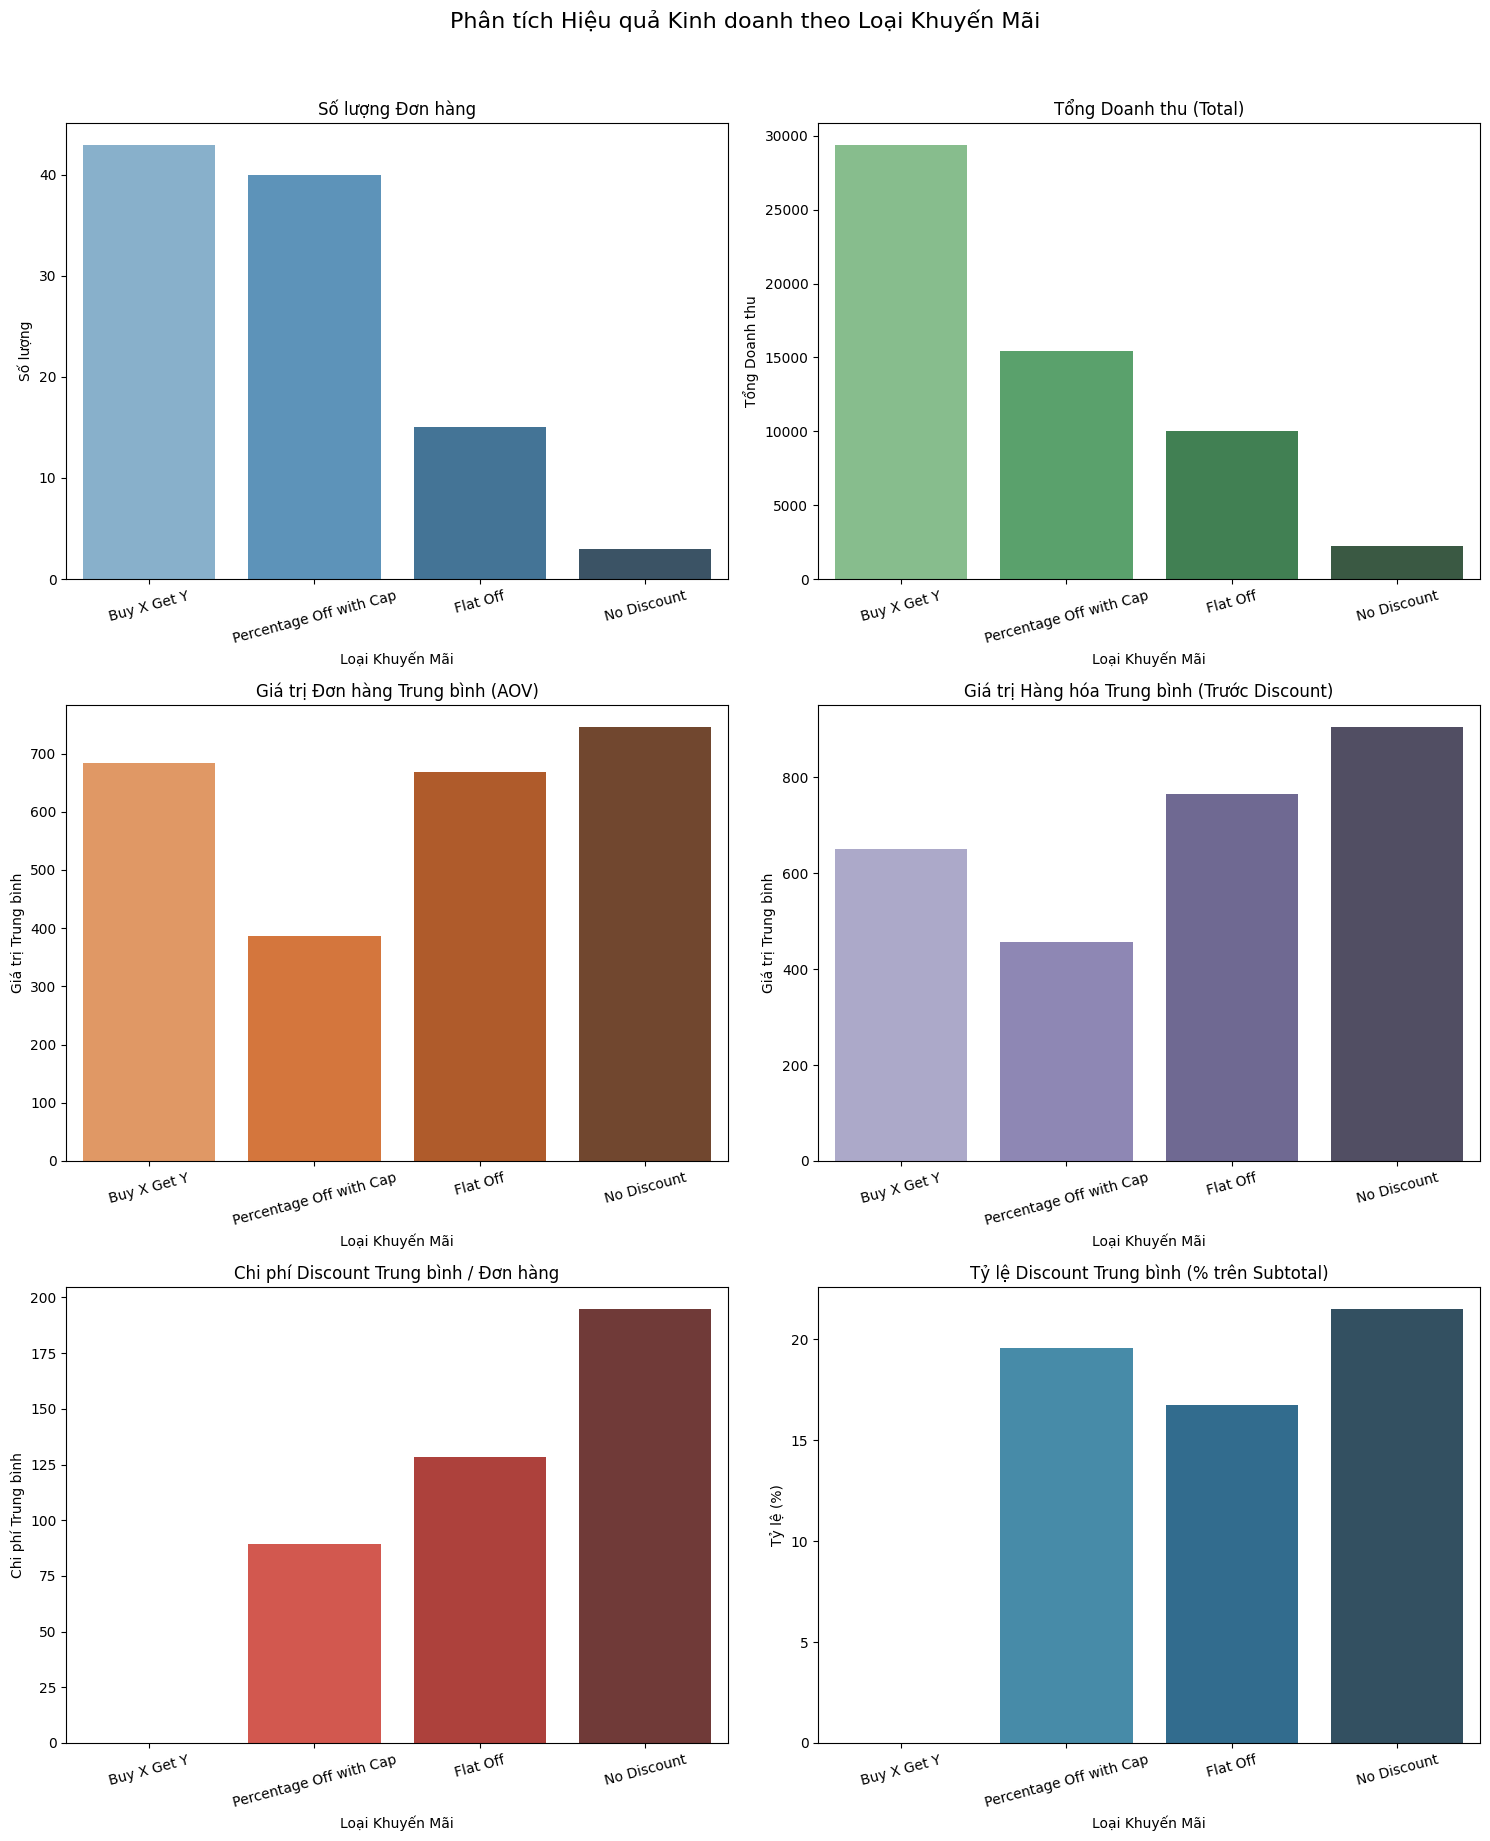

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Bước 1: Tổng hợp dữ liệu theo Discount Category ---
print("--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---")

# Tính tổng chi phí giảm giá số cho mỗi đơn hàng trước khi tổng hợp
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
df['Total Numerical Discount Cost'] = df[discount_cols_numeric].sum(axis=1)

# Thực hiện tổng hợp
agg_metrics = {
    'Order ID': ('Order ID', 'count'),           # Đếm số lượng đơn hàng
    'Total': ('Total', 'sum'),                  # Tổng doanh thu sau giảm giá
    'Bill subtotal': ('Bill subtotal', 'sum'),  # Tổng giá trị hàng hóa trước giảm giá
    'Total Numerical Discount Cost': ('Total Numerical Discount Cost', 'sum'), # Tổng chi phí giảm giá số
    'Packaging charges': ('Packaging charges', 'sum') # Tổng phí đóng gói
}

agg_df = df.groupby('Discount Category').agg(**agg_metrics).reset_index()

# Đổi tên cột cho rõ ràng hơn
agg_df.rename(columns={
    'Order ID': 'Số lượng đơn hàng',
    'Total': 'Tổng Doanh thu (Total)',
    'Bill subtotal': 'Tổng Giá trị hàng hóa (Subtotal)',
    'Total Numerical Discount Cost': 'Tổng Chi phí Discount',
    'Packaging charges': 'Tổng Phí Đóng gói'
}, inplace=True)

# Tính toán các chỉ số trung bình và tỷ lệ
agg_df['AOV (Average Total)'] = agg_df['Tổng Doanh thu (Total)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Bill Subtotal'] = agg_df['Tổng Giá trị hàng hóa (Subtotal)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Discount per Order'] = agg_df['Tổng Chi phí Discount'] / agg_df['Số lượng đơn hàng']
# Tránh chia cho 0 nếu Tổng Giá trị hàng hóa = 0
agg_df['Average Discount % (of Subtotal)'] = np.where(
    agg_df['Tổng Giá trị hàng hóa (Subtotal)'] > 0,
    (agg_df['Tổng Chi phí Discount'] / agg_df['Tổng Giá trị hàng hóa (Subtotal)']) * 100,
    0
)

# Sắp xếp theo số lượng đơn hàng để dễ so sánh
agg_df = agg_df.sort_values(by='Số lượng đơn hàng', ascending=False)

print("Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:")
# Định dạng số để dễ đọc hơn
pd.options.display.float_format = '{:,.2f}'.format
print(agg_df)
print("-" * 70)


# --- Bước 2: Trực quan hóa kết quả tổng hợp ---
print("\n--- Bước 2: Trực quan hóa Hiệu quả theo Loại Khuyến Mãi ---")

# Đặt lại định dạng float về mặc định để không ảnh hưởng các plot khác (nếu cần)
# pd.options.display.float_format = None

# Tạo subplot để vẽ nhiều biểu đồ
fig, axes = plt.subplots(3, 2, figsize=(15, 18)) # 3 hàng, 2 cột
fig.suptitle('Phân tích Hiệu quả Kinh doanh theo Loại Khuyến Mãi', fontsize=16, y=1.02)

# 1. Số lượng đơn hàng
sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
axes[0, 0].set_title('Số lượng Đơn hàng')
axes[0, 0].set_xlabel('Loại Khuyến Mãi')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Tổng Doanh thu (Total)
sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
axes[0, 1].set_title('Tổng Doanh thu (Total)')
axes[0, 1].set_xlabel('Loại Khuyến Mãi')
axes[0, 1].set_ylabel('Tổng Doanh thu')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. AOV (Average Total)
sns.barplot(ax=axes[1, 0], x='Discount Category', y='AOV (Average Total)', data=agg_df, palette='Oranges_d')
axes[1, 0].set_title('Giá trị Đơn hàng Trung bình (AOV)')
axes[1, 0].set_xlabel('Loại Khuyến Mãi')
axes[1, 0].set_ylabel('Giá trị Trung bình')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Average Bill Subtotal
sns.barplot(ax=axes[1, 1], x='Discount Category', y='Average Bill Subtotal', data=agg_df, palette='Purples_d')
axes[1, 1].set_title('Giá trị Hàng hóa Trung bình (Trước Discount)')
axes[1, 1].set_xlabel('Loại Khuyến Mãi')
axes[1, 1].set_ylabel('Giá trị Trung bình')
axes[1, 1].tick_params(axis='x', rotation=15)

# 5. Average Discount per Order
sns.barplot(ax=axes[2, 0], x='Discount Category', y='Average Discount per Order', data=agg_df, palette='Reds_d')
axes[2, 0].set_title('Chi phí Discount Trung bình / Đơn hàng')
axes[2, 0].set_xlabel('Loại Khuyến Mãi')
axes[2, 0].set_ylabel('Chi phí Trung bình')
axes[2, 0].tick_params(axis='x', rotation=15)

# 6. Average Discount % (of Subtotal)
sns.barplot(ax=axes[2, 1], x='Discount Category', y='Average Discount % (of Subtotal)', data=agg_df, palette='YlGnBu_d')
axes[2, 1].set_title('Tỷ lệ Discount Trung bình (% trên Subtotal)')
axes[2, 1].set_xlabel('Loại Khuyến Mãi')
axes[2, 1].set_ylabel('Tỷ lệ (%)')
axes[2, 1].tick_params(axis='x', rotation=15)

# Điều chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

# 8: Visualize các insight
- Phân bổ Đơn hàng theo Giờ trong Ngày
- Phân bổ đơn hàng theo Giờ và Loại Khuyến Mãi
- Số lượng Khách hàng Khác nhau theo Loại Khuyến Mãi
- Phân phối Tần suất Đặt hàng của Khách hàng


--- 3.1: Phân tích ANOVA trên Giá trị Đơn hàng Trung bình (AOV) ---

Xem xét lại ANOVA trên 'Total' (Phần 4) cho toàn bộ giai đoạn dữ liệu:
Bảng ANOVA cho Total:
                                sum_sq    df    F  PR(>F)
C(Q("Discount Category")) 2,154,677.21  3.00 8.16    0.00
Residual                  8,540,375.55 97.00  NaN     NaN

P-value cho sự khác biệt về 'Total' giữa các nhóm (toàn bộ dữ liệu): 0.0001
-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH tổng thể giữa các nhóm khuyến mãi.
   Điều này gợi ý mạnh mẽ rằng AOV (Average Total) cũng khác nhau giữa các nhóm khi xét trên toàn bộ giai đoạn.
----------------------------------------------------------------------

--- 3.2: Phân tích Phân bổ Đơn hàng theo Giờ trong Ngày (Toàn bộ Dữ liệu) ---


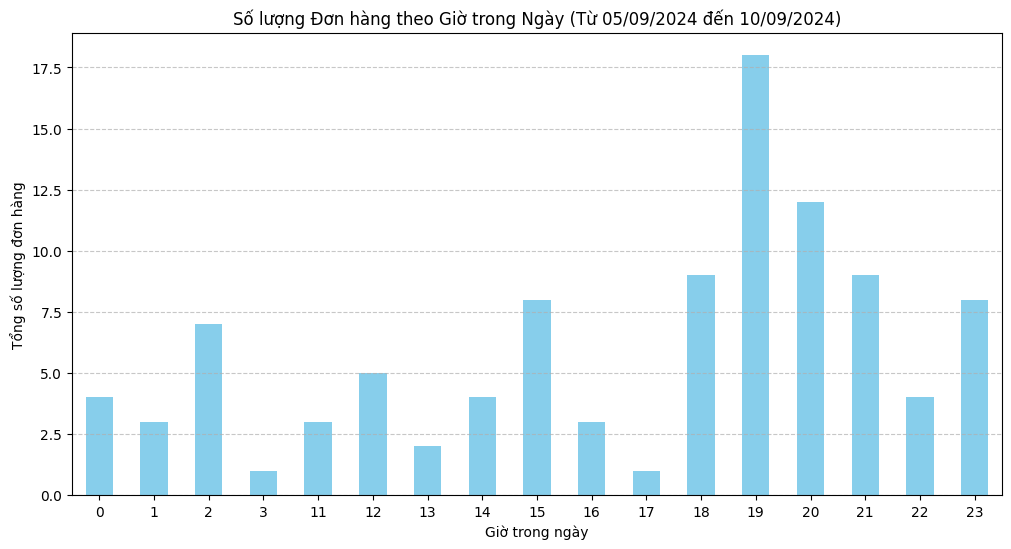


Phân bổ đơn hàng theo Giờ và Loại Khuyến Mãi (Toàn bộ Dữ liệu):
Discount Category  Buy X Get Y  Flat Off  No Discount  Percentage Off with Cap
Hour                                                                          
0                            0         2            0                        2
1                            0         0            0                        3
2                            0         2            1                        4
3                            0         0            0                        1
11                           2         0            0                        1
12                           3         0            0                        2
13                           2         0            0                        0
14                           3         0            0                        1
15                           2         0            0                        6
16                           2         1            0             

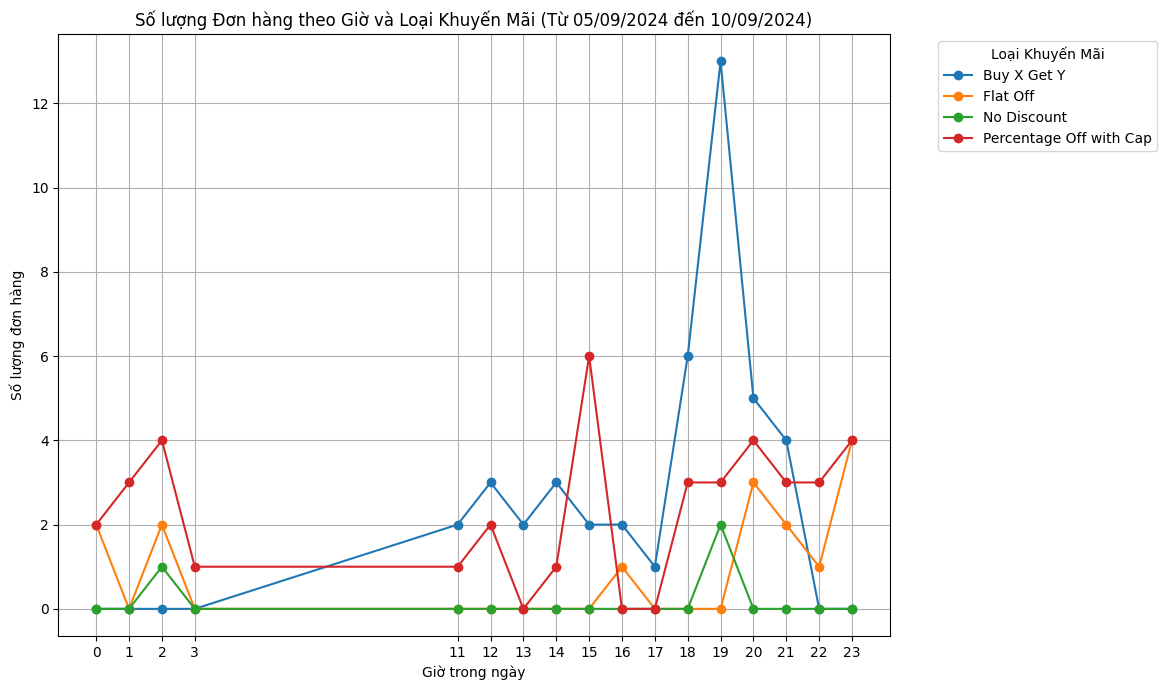

----------------------------------------------------------------------

--- 3.3: Phân tích Khách hàng Cơ bản ---

Số lượng Khách hàng Khác nhau theo Loại Khuyến Mãi:
Discount Category
Buy X Get Y                43
Percentage Off with Cap    38
Flat Off                   14
No Discount                 3
Name: Customer ID, dtype: int64


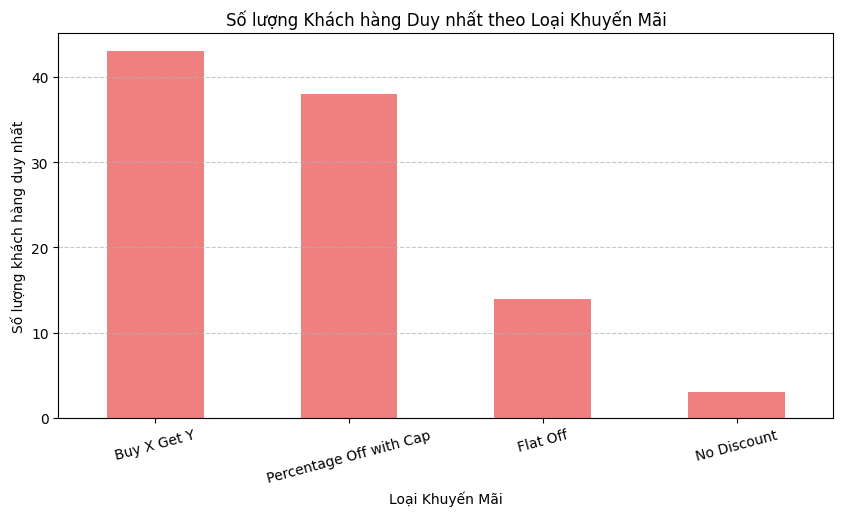


Phân phối Tần suất Đặt hàng của Khách hàng:
count   96.00
mean     1.05
std      0.22
min      1.00
25%      1.00
50%      1.00
75%      1.00
max      2.00
Name: count, dtype: float64


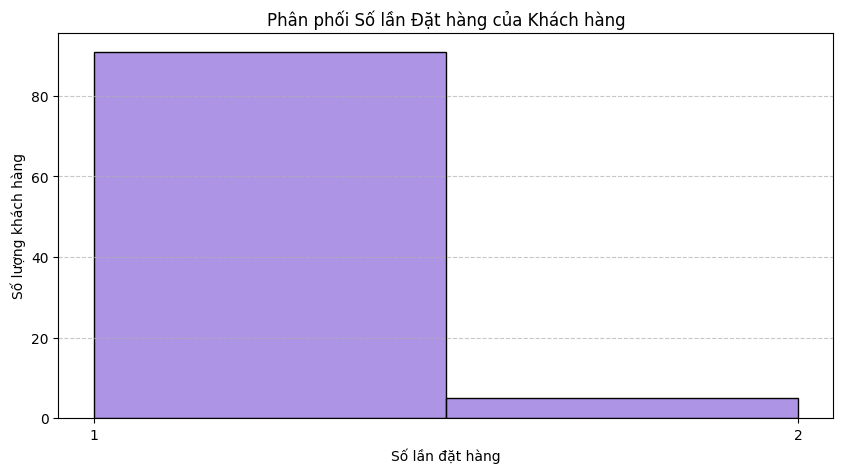


Trong tập dữ liệu này, có 96 khách hàng khác nhau.
Khách hàng đặt nhiều đơn nhất đã đặt: 2 đơn.
Số khách hàng chỉ đặt 1 đơn: 91.


In [25]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
import matplotlib.dates as mdates
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3.1: ANOVA trên Giá trị Đơn hàng Trung bình (AOV) - Diễn giải lại ---
print("\n--- 3.1: Phân tích ANOVA trên Giá trị Đơn hàng Trung bình (AOV) ---")
# Chúng ta vẫn dựa vào kết quả ANOVA trên 'Total' của df_anova (từ Phần 4)
# để đưa ra suy luận về sự khác biệt trung bình, bao gồm cả AOV.
# Phép kiểm định này so sánh giá trị trung bình TỔNG THỂ của các nhóm
# qua tất cả các ngày trong dữ liệu.

print("\nXem xét lại ANOVA trên 'Total' (Phần 4) cho toàn bộ giai đoạn dữ liệu:")
try:
    # Đảm bảo df_anova được định nghĩa đúng từ dữ liệu gốc df
    # Lọc các category có ít nhất 2 đơn hàng trong toàn bộ df
    category_counts_full = df['Discount Category'].value_counts()
    valid_categories_full = category_counts_full[category_counts_full >= 2].index.tolist()
    df_anova_full = df[df['Discount Category'].isin(valid_categories_full)].copy() # Tạo bản copy để tránh SettingWithCopyWarning

    if df_anova_full['Discount Category'].nunique() >= 2:
        model_anova_total = ols('Total ~ C(Q("Discount Category"))', data=df_anova_full).fit()
        anova_table_total = sm.stats.anova_lm(model_anova_total, typ=2)

        # Cần lấy giá trị p-value từ vị trí đúng trong bảng ANOVA
        # Tên index có thể là 'C(Q("Discount Category"))' hoặc tên cột
        if 'PR(>F)' in anova_table_total.columns:
             p_value_total = anova_table_total.loc[anova_table_total.index[0], 'PR(>F)'] # Lấy p-value của yếu tố Category
        else:
             print("Không tìm thấy cột 'PR(>F)' trong bảng ANOVA.")
             p_value_total = float('nan') # Gán giá trị không hợp lệ

        print(f"Bảng ANOVA cho Total:\n{anova_table_total}")
        print(f"\nP-value cho sự khác biệt về 'Total' giữa các nhóm (toàn bộ dữ liệu): {p_value_total:.4f}")

        if p_value_total < 0.05:
             print("-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH tổng thể giữa các nhóm khuyến mãi.")
             print("   Điều này gợi ý mạnh mẽ rằng AOV (Average Total) cũng khác nhau giữa các nhóm khi xét trên toàn bộ giai đoạn.")
             # (Bạn có thể thêm lại phần Tukey HSD ở đây nếu muốn xem cặp nào khác nhau)
             # from statsmodels.stats.multicomp import pairwise_tukeyhsd
             # tukey = pairwise_tukeyhsd(endog=df_anova_full['Total'], groups=df_anova_full['Discount Category'], alpha=0.05)
             # print("\nKiểm định Tukey HSD (So sánh từng cặp nhóm):")
             # print(tukey)
        else:
             print("-> Không có đủ bằng chứng cho thấy giá trị Total TRUNG BÌNH tổng thể khác biệt đáng kể giữa các nhóm khuyến mãi.")
    else:
         print("Không đủ nhóm (ít nhất 2) có đủ dữ liệu (ít nhất 2 đơn/nhóm) để chạy ANOVA trên Total.")

except NameError:
    print("Biến 'df' hoặc 'df_anova' chưa được định nghĩa.")
except KeyError as e:
    print(f"Lỗi KeyError khi truy cập bảng ANOVA, có thể tên cột/index không đúng: {e}")
    print("Bảng ANOVA nhận được:")
    try:
        print(anova_table_total)
    except NameError:
        print("Không thể in bảng ANOVA.")
except Exception as e:
    print(f"Lỗi khi thực hiện lại ANOVA trên Total: {e}")


print("-" * 70)


# --- 3.2: Phân tích Đơn hàng theo Giờ trong Ngày (Toàn bộ Dữ liệu) ---
print("\n--- 3.2: Phân tích Phân bổ Đơn hàng theo Giờ trong Ngày (Toàn bộ Dữ liệu) ---")
# Đảm bảo cột Hour đã được tạo
if 'Hour' not in df.columns:
     df['Hour'] = df['Order Placed At'].dt.hour

# Tổng hợp số đơn theo giờ trên toàn bộ dữ liệu
orders_by_hour_all = df.groupby('Hour')['Order ID'].count()

plt.figure(figsize=(12, 6))
orders_by_hour_all.plot(kind='bar', color='skyblue')
# Lấy ngày bắt đầu và kết thúc từ dữ liệu
start_date_str = df['Order Placed At'].dt.date.min().strftime('%d/%m/%Y')
end_date_str = df['Order Placed At'].dt.date.max().strftime('%d/%m/%Y')
plt.title(f'Số lượng Đơn hàng theo Giờ trong Ngày (Từ {start_date_str} đến {end_date_str})')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Tổng số lượng đơn hàng')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Phân tích theo giờ và loại discount trên toàn bộ dữ liệu
orders_by_hour_discount_all = df.groupby(['Hour', 'Discount Category'])['Order ID'].count().unstack(fill_value=0)

if not orders_by_hour_discount_all.empty:
    print("\nPhân bổ đơn hàng theo Giờ và Loại Khuyến Mãi (Toàn bộ Dữ liệu):")
    print(orders_by_hour_discount_all)
    orders_by_hour_discount_all.plot(kind='line', figsize=(14, 7), marker='o', linestyle='-')
    plt.title(f'Số lượng Đơn hàng theo Giờ và Loại Khuyến Mãi (Từ {start_date_str} đến {end_date_str})')
    plt.xlabel('Giờ trong ngày')
    plt.ylabel('Số lượng đơn hàng')
    # Lấy danh sách giờ duy nhất có trong dữ liệu
    hours_with_data = sorted(df['Hour'].unique())
    plt.xticks(hours_with_data) # Đặt ticks chỉ cho các giờ có dữ liệu
    plt.legend(title='Loại Khuyến Mãi', bbox_to_anchor=(1.05, 1), loc='upper left') # Đưa legend ra ngoài
    plt.grid(True)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Điều chỉnh layout để legend không bị che
    plt.show()
else:
    print("\nKhông có đủ dữ liệu để phân tích theo giờ và loại khuyến mãi.")

print("-" * 70)

# --- 3.3: Phân tích Khách hàng cơ bản ---
print("\n--- 3.3: Phân tích Khách hàng Cơ bản ---")

# Số lượng khách hàng khác nhau sử dụng từng loại khuyến mãi
customers_per_discount = df.groupby('Discount Category')['Customer ID'].nunique().sort_values(ascending=False)
print("\nSố lượng Khách hàng Khác nhau theo Loại Khuyến Mãi:")
print(customers_per_discount)

plt.figure(figsize=(10, 5))
customers_per_discount.plot(kind='bar', color='lightcoral')
plt.title('Số lượng Khách hàng Duy nhất theo Loại Khuyến Mãi')
plt.xlabel('Loại Khuyến Mãi')
plt.ylabel('Số lượng khách hàng duy nhất')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Phân tích tần suất đặt hàng của khách hàng
customer_frequency = df['Customer ID'].value_counts()
print("\nPhân phối Tần suất Đặt hàng của Khách hàng:")
print(customer_frequency.describe()) # Xem thống kê mô tả tần suất

plt.figure(figsize=(10, 5))
sns.histplot(customer_frequency, bins=max(1, customer_frequency.max()), kde=False, color='mediumpurple') # Số bins = số lần đặt hàng tối đa
plt.title('Phân phối Số lần Đặt hàng của Khách hàng')
plt.xlabel('Số lần đặt hàng')
plt.ylabel('Số lượng khách hàng')
plt.xticks(range(1, customer_frequency.max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nTrong tập dữ liệu này, có {df['Customer ID'].nunique()} khách hàng khác nhau.")
print(f"Khách hàng đặt nhiều đơn nhất đã đặt: {customer_frequency.max()} đơn.")
print(f"Số khách hàng chỉ đặt 1 đơn: {sum(customer_frequency == 1)}.")

# 9: Các dự đoán tương lai

## 9.1. Giảm mức Percentage Off
- Giả sử giảm mức giảm giá từ "40% off upto Rs.80" xuống "30% off upto Rs.60"
=> Ước tính chi phí discount mới cho nhóm này
=> Tính Tổng total ước tính mới


--- 1. Mô phỏng 'What-if': Thay đổi Percentage Off ---

Kịch bản: Giảm thành '30% off upto Rs.60' cho nhóm 'Percentage Off'
  - Số lượng đơn hàng giả định không đổi: 40
  - Average Bill Subtotal (giữ nguyên): 456.68
  - Average Discount / Đơn (Mới): 60.00
  - Tổng Chi phí Discount Thực tế: 3,571.62
  - Tổng Chi phí Discount Ước tính Mới: 2,400.00
  - Tổng Doanh thu (Total) Thực tế: 15,430.15
  - Tổng Doanh thu (Total) Ước tính Mới: 16,601.77
  - Thay đổi Doanh thu ước tính: 1,171.62
  - Thay đổi Chi phí Discount ước tính: -1,171.62

--- Trực quan hóa So sánh Kịch bản ---


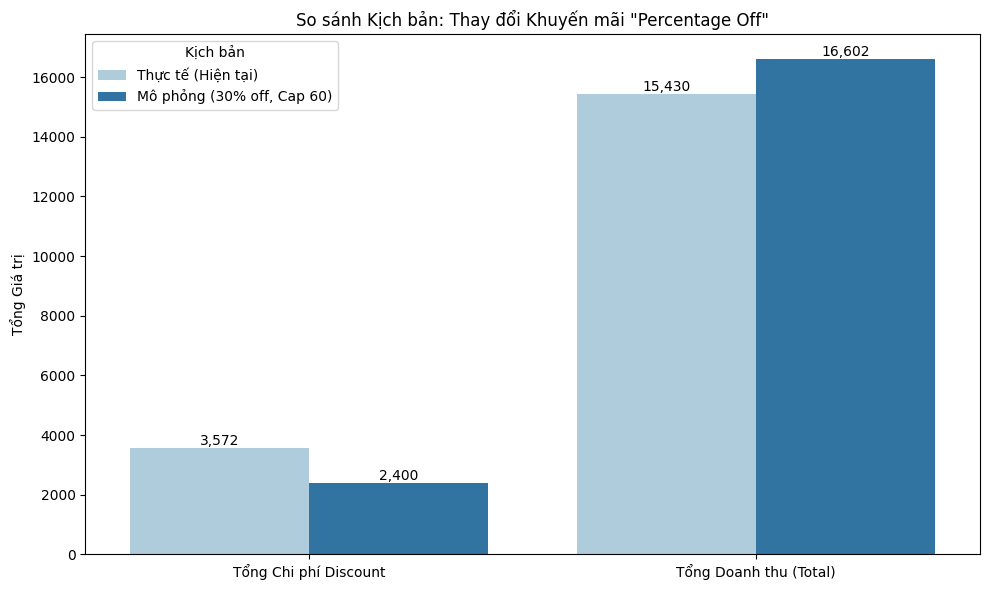

----------------------------------------------------------------------


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Mô phỏng "What-if": Giảm mức Percentage Off ---
print("\n--- 1. Mô phỏng 'What-if': Thay đổi Percentage Off ---")

# Lấy dữ liệu của nhóm 'Percentage Off with Cap' từ bảng agg_df
try:
    percent_off_data = agg_df[agg_df['Discount Category'] == 'Percentage Off with Cap'].iloc[0]

    # Dữ liệu thực tế
    total_discount_cost_actual = percent_off_data['Tổng Chi phí Discount']
    total_revenue_actual = percent_off_data['Tổng Doanh thu (Total)']
    avg_subtotal_percent_off = percent_off_data['Average Bill Subtotal']
    total_orders_percent_off = percent_off_data['Số lượng đơn hàng']
    total_subtotal_percent_off = percent_off_data['Tổng Giá trị hàng hóa (Subtotal)']
    total_packaging_percent_off = percent_off_data['Tổng Phí Đóng gói']

    # --- Tính toán Kịch bản mới ---
    # Kịch bản mới: 30% off upto Rs.60
    new_discount_percent = 0.30
    new_discount_cap = 60.0

    avg_discount_new = min(avg_subtotal_percent_off * new_discount_percent, new_discount_cap)
    total_discount_cost_new = avg_discount_new * total_orders_percent_off
    total_revenue_new = total_subtotal_percent_off - total_discount_cost_new + total_packaging_percent_off

    # --- In kết quả tính toán (như trước) ---
    print(f"\nKịch bản: Giảm thành '30% off upto Rs.60' cho nhóm 'Percentage Off'")
    print(f"  - Số lượng đơn hàng giả định không đổi: {total_orders_percent_off:,.0f}")
    print(f"  - Average Bill Subtotal (giữ nguyên): {avg_subtotal_percent_off:,.2f}")
    print(f"  - Average Discount / Đơn (Mới): {avg_discount_new:,.2f}")
    print(f"  - Tổng Chi phí Discount Thực tế: {total_discount_cost_actual:,.2f}")
    print(f"  - Tổng Chi phí Discount Ước tính Mới: {total_discount_cost_new:,.2f}")
    print(f"  - Tổng Doanh thu (Total) Thực tế: {total_revenue_actual:,.2f}")
    print(f"  - Tổng Doanh thu (Total) Ước tính Mới: {total_revenue_new:,.2f}")
    print(f"  - Thay đổi Doanh thu ước tính: {total_revenue_new - total_revenue_actual:,.2f}")
    print(f"  - Thay đổi Chi phí Discount ước tính: {total_discount_cost_new - total_discount_cost_actual:,.2f}")


    # --- Trực quan hóa So sánh ---
    print("\n--- Trực quan hóa So sánh Kịch bản ---")

    # Chuẩn bị dữ liệu cho biểu đồ
    plot_data = pd.DataFrame({
        'Chỉ số': ['Tổng Chi phí Discount', 'Tổng Doanh thu (Total)', 'Tổng Chi phí Discount', 'Tổng Doanh thu (Total)'],
        'Kịch bản': ['Thực tế (Hiện tại)', 'Thực tế (Hiện tại)', 'Mô phỏng (30% off, Cap 60)', 'Mô phỏng (30% off, Cap 60)'],
        'Giá trị': [total_discount_cost_actual, total_revenue_actual, total_discount_cost_new, total_revenue_new]
    })

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Chỉ số', y='Giá trị', hue='Kịch bản', data=plot_data, palette='Paired')

    # Thêm giá trị lên trên các cột
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}') # Định dạng số nguyên

    plt.title('So sánh Kịch bản: Thay đổi Khuyến mãi "Percentage Off"')
    plt.ylabel('Tổng Giá trị')
    plt.xlabel('') # Có thể bỏ trống hoặc ghi 'Chỉ số so sánh'
    plt.xticks(rotation=0)
    plt.legend(title='Kịch bản')
    plt.tight_layout()
    plt.show()

except IndexError:
    print("Không tìm thấy nhóm 'Percentage Off with Cap' trong dữ liệu tổng hợp để mô phỏng.")
except KeyError as e:
     print(f"Thiếu cột cần thiết trong agg_df để mô phỏng: {e}")


print("-" * 70)

## 9.2. Dự đoán AOV dựa trên Loại Khuyến mãi
- Dự đoán xem nếu chỉ biết loại khuyến mãi sắp tới được áp dụng, thì giá trị đơn hàng trung bình (AOV) dự kiến sẽ là bao nhiêu
- Nếu áp dụng khuyến mãi 'Buy X Get Y', AOV dự kiến sẽ là [giá trị AOV của nhóm 'Buy X Get Y' trong quá khứ]



--- 2. Phân bổ Total và AOV Dự kiến theo Loại Khuyến mãi ---
AOV Dự kiến cho từng Loại Khuyến Mãi (dựa trên dữ liệu quá khứ):
                         AOV Dự kiến
Buy X Get Y                   683.97
Percentage Off with Cap       385.75
Flat Off                      669.06
No Discount                   746.24


<ipython-input-36-5783ab634f91>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Discount Category', y='Total', data=df, palette='viridis', showfliers=True) # showfliers=True để hiện các điểm ngoại lệ


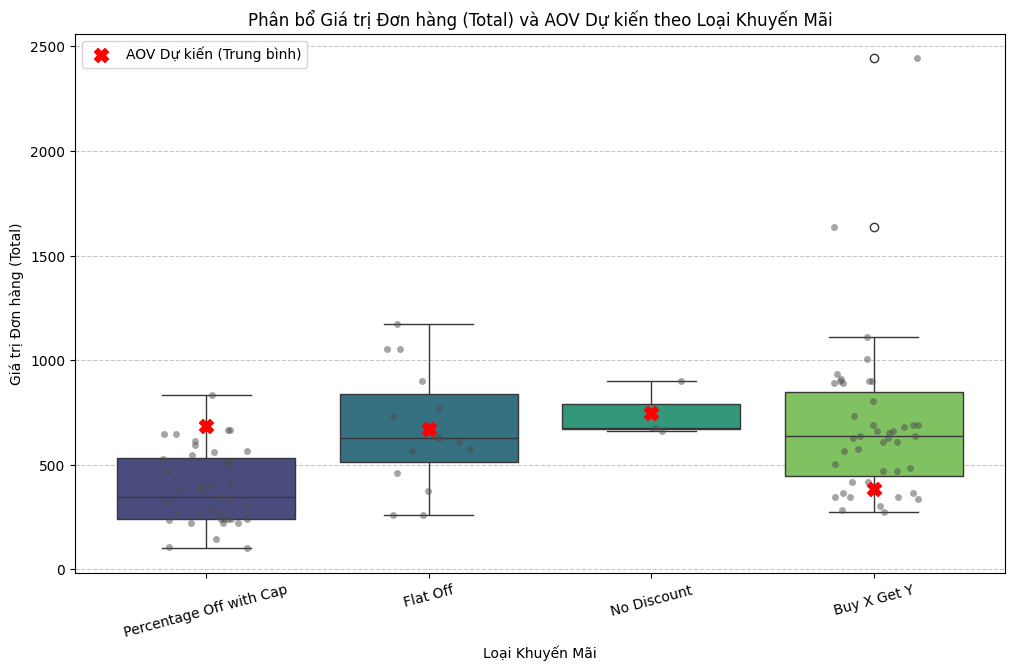


Giải thích biểu đồ:
- Biểu đồ này thể hiện sự phân bổ của giá trị 'Total' cho các đơn hàng thuộc từng loại khuyến mãi.
- Mỗi 'hộp' (boxplot) cho thấy khoảng tứ phân vị (IQR - 50% dữ liệu ở giữa), đường kẻ ngang giữa hộp là trung vị (median).
- Các điểm đen nhỏ (stripplot) là các giá trị 'Total' thực tế của từng đơn hàng.
- Điểm 'X' màu đỏ đánh dấu giá trị trung bình (AOV) của mỗi nhóm - đây là 'AOV dự kiến' đơn giản nhất nếu bạn áp dụng loại khuyến mãi đó.
- Bạn có thể thấy mức độ tập trung/phân tán của các đơn hàng quanh AOV dự kiến và liệu có các đơn hàng ngoại lệ (giá trị rất cao/thấp) hay không.
- Ví dụ: Nếu một hộp rất hẹp và các điểm tập trung gần dấu X đỏ, thì AOV dự kiến đó khá đáng tin cậy cho nhóm đó. Nếu hộp rộng hoặc có nhiều điểm xa dấu X, AOV trung bình có thể bị ảnh hưởng bởi các giá trị cực đoan.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 2. Trực quan hóa Phân bổ Total và AOV Dự kiến theo Loại Khuyến mãi ---
print("\n--- 2. Phân bổ Total và AOV Dự kiến theo Loại Khuyến mãi ---")

# Sử dụng DataFrame gốc 'df' đã có cột 'Discount Category'
# và bảng tổng hợp 'agg_df' để lấy AOV dự kiến

# Lấy AOV dự kiến từ bảng tổng hợp để tham chiếu
aov_predictions_dict = agg_df.set_index('Discount Category')['AOV (Average Total)'].to_dict()
print("AOV Dự kiến cho từng Loại Khuyến Mãi (dựa trên dữ liệu quá khứ):")
print(pd.Series(aov_predictions_dict).to_frame(name='AOV Dự kiến'))


# Trực quan hóa phân bổ và giá trị trung bình
plt.figure(figsize=(12, 7))

# Boxplot để thấy phân vị và ngoại lệ
sns.boxplot(x='Discount Category', y='Total', data=df, palette='viridis', showfliers=True) # showfliers=True để hiện các điểm ngoại lệ

# Stripplot để thấy các điểm dữ liệu thực tế (đặc biệt hữu ích cho nhóm nhỏ)
sns.stripplot(x='Discount Category', y='Total', data=df, color=".3", alpha=0.5, jitter=0.2) # jitter để điểm không chồng lên nhau quá nhiều

# Đánh dấu AOV dự kiến (giá trị trung bình)
# Lấy vị trí x (0, 1, 2, ...) và giá trị AOV tương ứng
categories = sorted(df['Discount Category'].unique()) # Sắp xếp để đảm bảo thứ tự khớp với plot
aov_values = [aov_predictions_dict.get(cat, np.nan) for cat in categories] # Lấy AOV theo đúng thứ tự
plt.scatter(range(len(categories)), aov_values, marker='X', color='red', s=100, zorder=5, label='AOV Dự kiến (Trung bình)') # zorder để điểm nằm trên


plt.title('Phân bổ Giá trị Đơn hàng (Total) và AOV Dự kiến theo Loại Khuyến Mãi')
plt.xlabel('Loại Khuyến Mãi')
plt.ylabel('Giá trị Đơn hàng (Total)')
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nGiải thích biểu đồ:")
print("- Biểu đồ này thể hiện sự phân bổ của giá trị 'Total' cho các đơn hàng thuộc từng loại khuyến mãi.")
print("- Mỗi 'hộp' (boxplot) cho thấy khoảng tứ phân vị (IQR - 50% dữ liệu ở giữa), đường kẻ ngang giữa hộp là trung vị (median).")
print("- Các điểm đen nhỏ (stripplot) là các giá trị 'Total' thực tế của từng đơn hàng.")
print("- Điểm 'X' màu đỏ đánh dấu giá trị trung bình (AOV) của mỗi nhóm - đây là 'AOV dự kiến' đơn giản nhất nếu bạn áp dụng loại khuyến mãi đó.")
print("- Bạn có thể thấy mức độ tập trung/phân tán của các đơn hàng quanh AOV dự kiến và liệu có các đơn hàng ngoại lệ (giá trị rất cao/thấp) hay không.")
print("- Ví dụ: Nếu một hộp rất hẹp và các điểm tập trung gần dấu X đỏ, thì AOV dự kiến đó khá đáng tin cậy cho nhóm đó. Nếu hộp rộng hoặc có nhiều điểm xa dấu X, AOV trung bình có thể bị ảnh hưởng bởi các giá trị cực đoan.")

## 9.3. Dự đoán tổng total ngày kế tiếp

### Bước 1: Chuẩn bị dữ liệu Chuỗi thời gian


--- Chuẩn bị Dữ liệu Chuỗi Thời gian ---

Bảng tổng hợp dữ liệu hàng ngày:
            Daily_Orders  Daily_Total_Revenue  Daily_Avg_Bill_Subtotal  \
Order Date                                                               
2024-09-05            11             6,077.40                   674.45   
2024-09-06            63            38,704.45                   617.78   
2024-09-07             7             3,049.20                   514.14   
2024-09-08            10             4,258.91                   485.61   
2024-09-09             3               995.40                   396.00   
2024-09-10             7             4,029.90                   641.86   

            Daily_Avg_Total_Discount  Daily_AOV  
Order Date                                       
2024-09-05                    148.27     552.49  
2024-09-06                     32.68     614.36  
2024-09-07                     99.29     435.60  
2024-09-08                     80.00     425.89  
2024-09-09                     

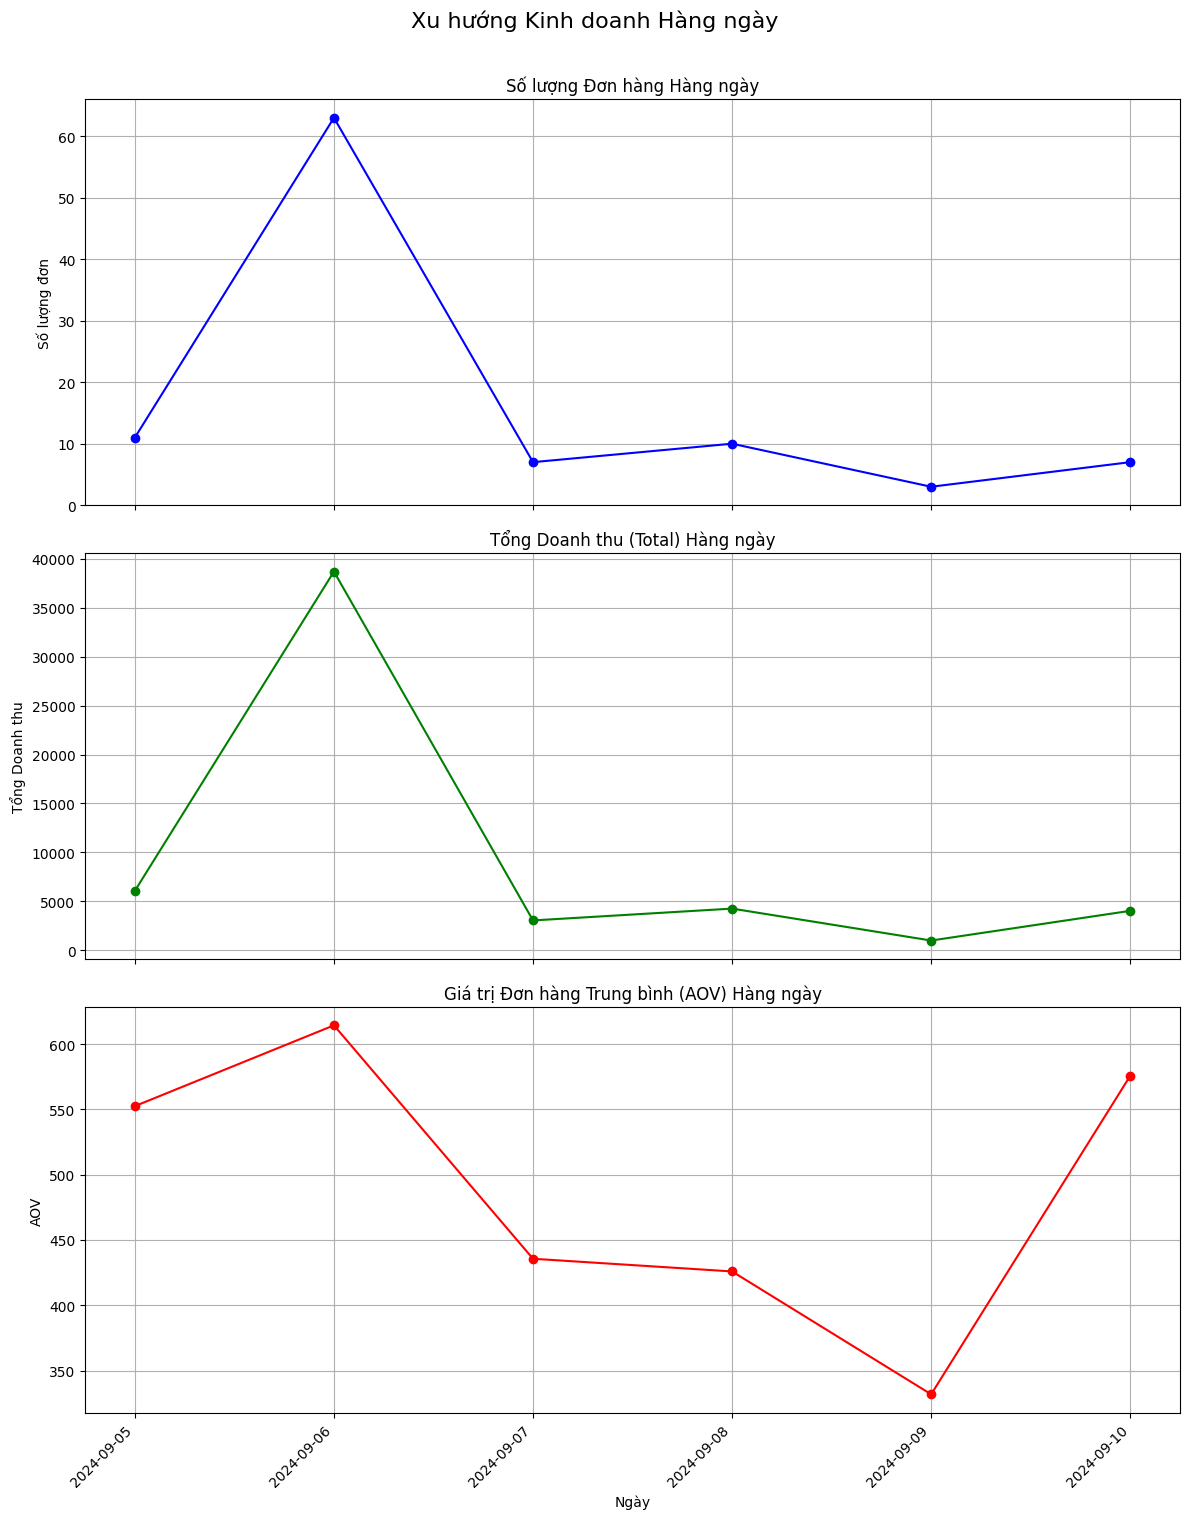


Giải thích biểu đồ chuỗi thời gian:
- Các biểu đồ này cho thấy sự biến động của số lượng đơn hàng, tổng doanh thu và AOV qua các ngày trong tập dữ liệu của bạn.
- Bạn có thể quan sát xem có ngày nào có số lượng đơn/doanh thu đột biến hay không (ví dụ: cuối tuần so với ngày thường?).
- Với khoảng thời gian ngắn (5-6 ngày), việc xác định xu hướng dài hạn hoặc tính thời vụ rõ ràng là rất khó.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- Đảm bảo DataFrame 'df' đã được tải và có cột 'Order Placed At' đúng định dạng ---
# (Tải lại df nếu cần)
# try:
#     df = pd.read_csv('your_updated_data.csv') # Thay bằng tên file đúng
# except UnicodeDecodeError:
#     try:
#         df = pd.read_csv('your_updated_data.csv', encoding='latin1')
#     except Exception as e:
#         print(f"Lỗi khi đọc file CSV: {e}")
#         # exit() # Thoát nếu không đọc được file

# df.columns = df.columns.str.strip()

# --- Chuẩn bị Dữ liệu Thời gian ---
print("\n--- Chuẩn bị Dữ liệu Chuỗi Thời gian ---")

# Chuyển đổi sang datetime và xử lý lỗi nếu có
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
# Loại bỏ các dòng có ngày giờ không hợp lệ (nếu có)
df.dropna(subset=['Order Placed At'], inplace=True)

# Trích xuất Ngày
df['Order Date'] = df['Order Placed At'].dt.date
df['Order Date'] = pd.to_datetime(df['Order Date']) # Chuyển lại thành datetime để dễ xử lý

# --- Tổng hợp dữ liệu theo Ngày ---
daily_summary = df.groupby('Order Date').agg(
    Daily_Orders=('Order ID', 'count'),
    Daily_Total_Revenue=('Total', 'sum'),
    Daily_Avg_Bill_Subtotal=('Bill subtotal', 'mean'),
    Daily_Avg_Total_Discount=('Total Numerical Discount Cost', 'mean') # Giả sử cột này đã được tạo
).reset_index()

# Tính AOV hàng ngày
daily_summary['Daily_AOV'] = daily_summary['Daily_Total_Revenue'] / daily_summary['Daily_Orders']

# Đặt Ngày làm chỉ mục để dễ dàng phân tích chuỗi thời gian
daily_summary.set_index('Order Date', inplace=True)

# Sắp xếp theo ngày
daily_summary.sort_index(inplace=True)

print("\nBảng tổng hợp dữ liệu hàng ngày:")
print(daily_summary)
print("-" * 70)

# --- Trực quan hóa dữ liệu chuỗi thời gian ---
print("\n--- Trực quan hóa Dữ liệu Chuỗi Thời gian Hàng ngày ---")

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True) # 3 hàng, 1 cột, chia sẻ trục X
fig.suptitle('Xu hướng Kinh doanh Hàng ngày', fontsize=16, y=1.01)

# 1. Số lượng đơn hàng hàng ngày
axes[0].plot(daily_summary.index, daily_summary['Daily_Orders'], marker='o', linestyle='-', color='b')
axes[0].set_title('Số lượng Đơn hàng Hàng ngày')
axes[0].set_ylabel('Số lượng đơn')
axes[0].grid(True)

# 2. Tổng doanh thu hàng ngày
axes[1].plot(daily_summary.index, daily_summary['Daily_Total_Revenue'], marker='o', linestyle='-', color='g')
axes[1].set_title('Tổng Doanh thu (Total) Hàng ngày')
axes[1].set_ylabel('Tổng Doanh thu')
axes[1].grid(True)

# 3. AOV hàng ngày
axes[2].plot(daily_summary.index, daily_summary['Daily_AOV'], marker='o', linestyle='-', color='r')
axes[2].set_title('Giá trị Đơn hàng Trung bình (AOV) Hàng ngày')
axes[2].set_ylabel('AOV')
axes[2].set_xlabel('Ngày')
axes[2].grid(True)

# Định dạng trục X để hiển thị ngày rõ ràng hơn
for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1)) # Hiển thị mỗi ngày
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nGiải thích biểu đồ chuỗi thời gian:")
print("- Các biểu đồ này cho thấy sự biến động của số lượng đơn hàng, tổng doanh thu và AOV qua các ngày trong tập dữ liệu của bạn.")
print("- Bạn có thể quan sát xem có ngày nào có số lượng đơn/doanh thu đột biến hay không (ví dụ: cuối tuần so với ngày thường?).")
print("- Với khoảng thời gian ngắn (5-6 ngày), việc xác định xu hướng dài hạn hoặc tính thời vụ rõ ràng là rất khó.")

### Bước 2: Áp dụng Mô hình Dự báo Moving Average


--- Dự báo cho Ngày Tiếp theo bằng Trung bình Trượt (SMA) ---

Dự báo cho ngày: 2024-09-11 (dựa trên SMA 2 ngày)
  - Số lượng đơn hàng dự kiến: 5.0
  - Tổng Doanh thu (Total) dự kiến: 2,512.65


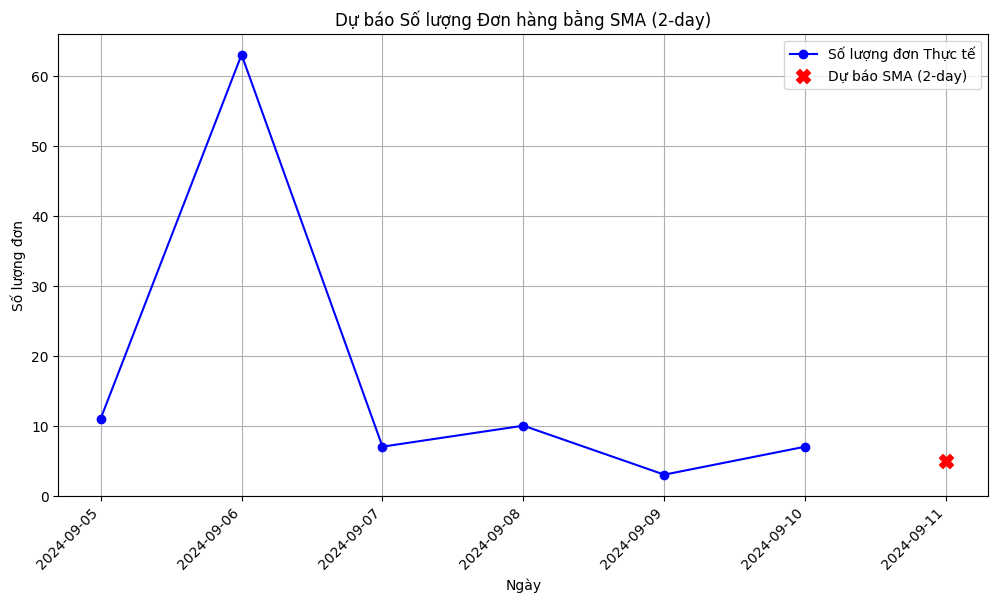

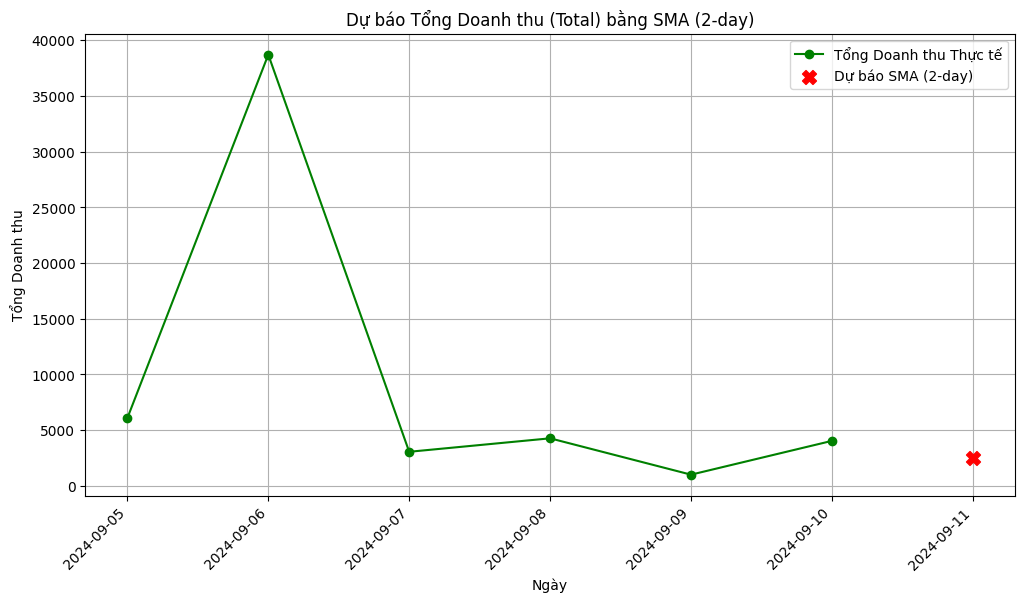

----------------------------------------------------------------------
LƯU Ý QUAN TRỌNG:
- Đây là dự báo rất cơ bản và độ tin cậy thấp do khoảng thời gian dữ liệu ngắn.
- Mô hình này không tính đến các yếu tố như ngày trong tuần, sự kiện đặc biệt, hay tác động cụ thể của từng loại khuyến mãi đang chạy vào ngày đó.
- Để dự báo chính xác hơn, cần dữ liệu dài hơn và các mô hình phức tạp hơn (ARIMA, Prophet, mô hình học máy có tính thời gian).


In [22]:
# --- Bước 2: Dự báo bằng Trung bình trượt Đơn giản (SMA) ---
print("\n--- Dự báo cho Ngày Tiếp theo bằng Trung bình Trượt (SMA) ---")

window_size = 2 # Chọn cửa sổ là 2 ngày gần nhất (có thể thay đổi thành 3 nếu muốn)

if len(daily_summary) >= window_size:
    # Dự báo Số lượng đơn hàng
    last_k_days_orders = daily_summary['Daily_Orders'].iloc[-window_size:]
    predicted_orders_sma = last_k_days_orders.mean()

    # Dự báo Tổng doanh thu
    last_k_days_revenue = daily_summary['Daily_Total_Revenue'].iloc[-window_size:]
    predicted_revenue_sma = last_k_days_revenue.mean()

    # Ngày dự báo
    last_date = daily_summary.index[-1]
    forecast_date = last_date + pd.Timedelta(days=1)

    print(f"\nDự báo cho ngày: {forecast_date.strftime('%Y-%m-%d')} (dựa trên SMA {window_size} ngày)")
    print(f"  - Số lượng đơn hàng dự kiến: {predicted_orders_sma:,.1f}")
    print(f"  - Tổng Doanh thu (Total) dự kiến: {predicted_revenue_sma:,.2f}")

    # --- Trực quan hóa Dự báo ---
    plt.figure(figsize=(12, 6))
    plt.plot(daily_summary.index, daily_summary['Daily_Orders'], marker='o', linestyle='-', color='b', label='Số lượng đơn Thực tế')
    # Vẽ điểm dự báo
    plt.scatter([forecast_date], [predicted_orders_sma], color='red', marker='X', s=100, label=f'Dự báo SMA ({window_size}-day)', zorder=5)
    plt.title(f'Dự báo Số lượng Đơn hàng bằng SMA ({window_size}-day)')
    plt.ylabel('Số lượng đơn')
    plt.xlabel('Ngày')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(daily_summary.index, daily_summary['Daily_Total_Revenue'], marker='o', linestyle='-', color='g', label='Tổng Doanh thu Thực tế')
    # Vẽ điểm dự báo
    plt.scatter([forecast_date], [predicted_revenue_sma], color='red', marker='X', s=100, label=f'Dự báo SMA ({window_size}-day)', zorder=5)
    plt.title(f'Dự báo Tổng Doanh thu (Total) bằng SMA ({window_size}-day)')
    plt.ylabel('Tổng Doanh thu')
    plt.xlabel('Ngày')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.show()

else:
    print(f"Không đủ dữ liệu (cần ít nhất {window_size} ngày) để thực hiện dự báo SMA.")

print("-" * 70)
print("LƯU Ý QUAN TRỌNG:")
print("- Đây là dự báo rất cơ bản và độ tin cậy thấp do khoảng thời gian dữ liệu ngắn.")
print("- Mô hình này không tính đến các yếu tố như ngày trong tuần, sự kiện đặc biệt, hay tác động cụ thể của từng loại khuyến mãi đang chạy vào ngày đó.")
print("- Để dự báo chính xác hơn, cần dữ liệu dài hơn và các mô hình phức tạp hơn (ARIMA, Prophet, mô hình học máy có tính thời gian).")

## 9.4. Mô phỏng Kịch bản Hỗn hợp Khuyến mãi
Mô phỏng 2 kịch bản cho 7 ngày tới:
- Kịch bản A: Chỉ chạy "Buy X Get Y" và "Percentage Off with Cap".
- Kịch bản B: Chỉ chạy "Flat Off" và "Percentage Off with Cap".

### Bước 1: Tính toán Số liệu Trung bình Hàng ngày cho Mỗi Loại Khuyến mãi
Ta cần biết trung bình mỗi ngày, mỗi loại khuyến mãi tạo ra bao nhiêu đơn hàng, doanh thu, v.v.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Tính toán số ngày có dữ liệu ---
num_days_in_data = (df['Order Date'].max() - df['Order Date'].min()).days + 1
print(f"Số ngày có dữ liệu trong tập mẫu: {num_days_in_data}")

# --- Tính toán Số liệu Trung bình Hàng ngày ---
# Sử dụng bảng agg_df đã tạo ở Bước 1 của phần trước

# Chia các giá trị tổng cho số ngày để có giá trị trung bình hàng ngày
# Lưu ý: Giả định rằng mỗi loại KM chạy trong suốt thời gian có dữ liệu
# Điều này có thể không hoàn toàn chính xác nếu một KM chỉ chạy 1-2 ngày
agg_df['Avg Daily Orders'] = agg_df['Số lượng đơn hàng'] / num_days_in_data
agg_df['Avg Daily Revenue'] = agg_df['Tổng Doanh thu (Total)'] / num_days_in_data
agg_df['Avg Daily Subtotal'] = agg_df['Tổng Giá trị hàng hóa (Subtotal)'] / num_days_in_data
agg_df['Avg Daily Discount Cost'] = agg_df['Tổng Chi phí Discount'] / num_days_in_data
agg_df['Avg Daily Packaging Cost'] = agg_df['Tổng Phí Đóng gói'] / num_days_in_data


print("\nBảng tổng hợp với số liệu trung bình hàng ngày (ước tính):")
print(agg_df[['Discount Category', 'Avg Daily Orders', 'Avg Daily Revenue', 'Avg Daily Subtotal', 'Avg Daily Discount Cost', 'AOV (Average Total)', 'Average Bill Subtotal']])
print("-" * 70)

Số ngày có dữ liệu trong tập mẫu: 6

Bảng tổng hợp với số liệu trung bình hàng ngày (ước tính):
         Discount Category  Avg Daily Orders  Avg Daily Revenue  \
0              Buy X Get Y              7.17           4,901.75   
3  Percentage Off with Cap              6.67           2,571.69   
1                 Flat Off              2.50           1,672.65   
2              No Discount              0.50             373.12   

   Avg Daily Subtotal  Avg Daily Discount Cost  AOV (Average Total)  \
0            4,668.33                     0.00               683.97   
3            3,044.50                   595.27               385.75   
1            1,913.50                   320.50               669.06   
2              452.85                    97.50               746.24   

   Average Bill Subtotal  
0                 651.40  
3                 456.68  
1                 765.40  
2                 905.70  
----------------------------------------------------------------------


### Bước 2: Định nghĩa và Mô phỏng các Kịch bản


--- Mô phỏng Kịch bản Hỗn hợp Khuyến mãi cho 1 Tuần (7 ngày) ---
*** CẢNH BÁO: Kết quả chỉ là ước tính dựa trên trung bình quá khứ ngắn hạn! ***

Kịch bản A (Ước tính cho 7 ngày): Chỉ chạy Buy X Get Y + Percentage Off
  - Tổng số đơn hàng ước tính: 96.8
  - Tổng doanh thu (Total) ước tính: 52,314.09
  - Tổng chi phí Discount ước tính: 4,166.89
  - AOV (Average Total) ước tính: 540.25

Kịch bản B (Ước tính cho 7 ngày): Chỉ chạy Flat Off + Percentage Off
  - Tổng số đơn hàng ước tính: 64.2
  - Tổng doanh thu (Total) ước tính: 29,710.39
  - Tổng chi phí Discount ước tính: 6,410.39
  - AOV (Average Total) ước tính: 463.02
----------------------------------------------------------------------

--- Trực quan hóa So sánh các Kịch bản Mô phỏng (Ước tính 7 ngày) ---


<ipython-input-24-c09efffdf259>:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Số Đơn hàng'], palette='Accent')
<ipython-input-24-c09efffdf259>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Doanh thu (Total)'], palette='Accent')
<ipython-input-24-c09efffdf259>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='Kịch

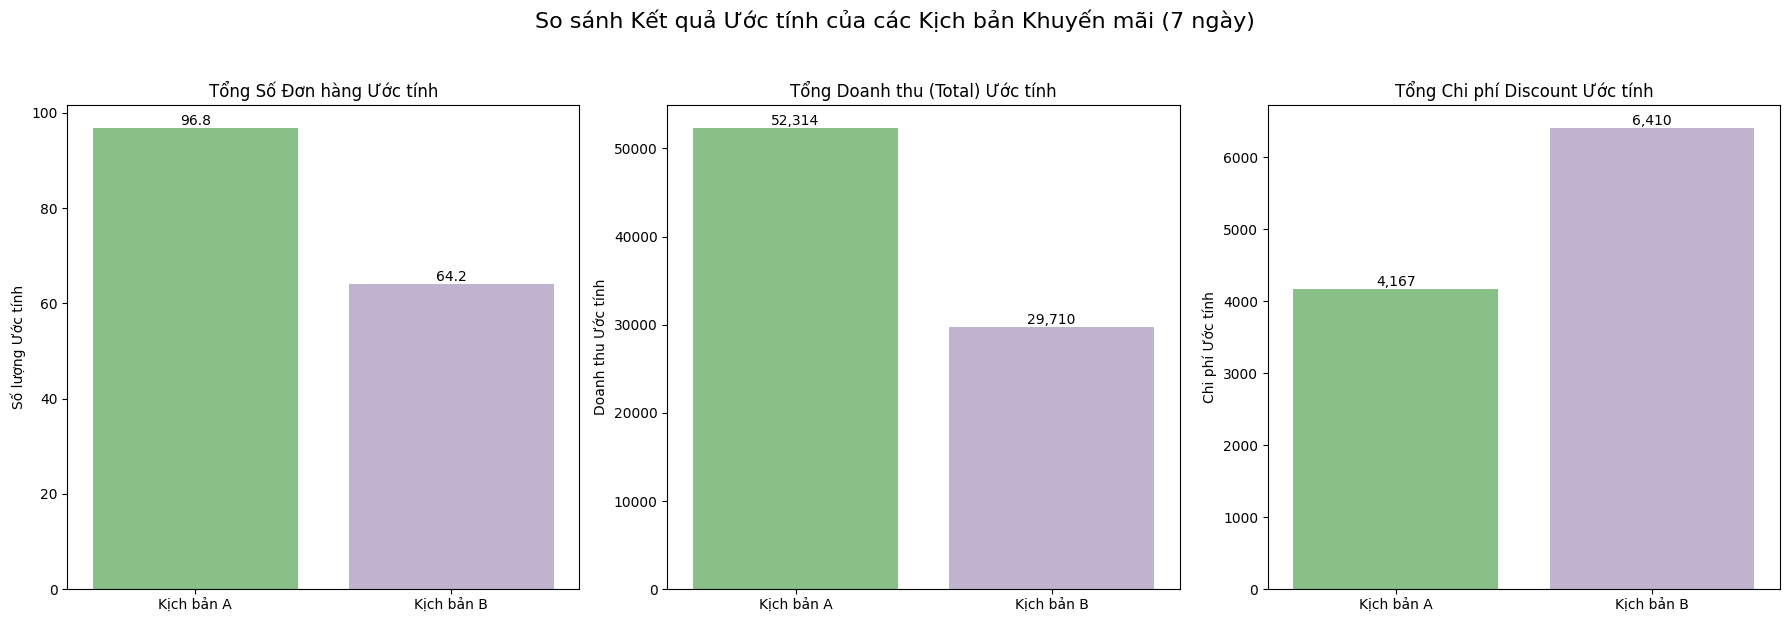

In [24]:
# --- Bước 2: Mô phỏng Kịch bản Hỗn hợp Khuyến mãi ---
print("\n--- Mô phỏng Kịch bản Hỗn hợp Khuyến mãi cho 1 Tuần (7 ngày) ---")
print("*** CẢNH BÁO: Kết quả chỉ là ước tính dựa trên trung bình quá khứ ngắn hạn! ***")

forecast_horizon_days = 7

# --- Kịch bản A: Buy X Get Y + Percentage Off ---
scenario_A_promos = ['Buy X Get Y', 'Percentage Off with Cap']
scenario_A_data = agg_df[agg_df['Discount Category'].isin(scenario_A_promos)]

if not scenario_A_data.empty:
    est_A_orders = scenario_A_data['Avg Daily Orders'].sum() * forecast_horizon_days
    est_A_revenue = scenario_A_data['Avg Daily Revenue'].sum() * forecast_horizon_days
    est_A_discount_cost = scenario_A_data['Avg Daily Discount Cost'].sum() * forecast_horizon_days
    est_A_subtotal = scenario_A_data['Avg Daily Subtotal'].sum() * forecast_horizon_days
    # Ước tính AOV tổng thể cho kịch bản này
    est_A_aov = est_A_revenue / est_A_orders if est_A_orders > 0 else 0

    print("\nKịch bản A (Ước tính cho 7 ngày): Chỉ chạy Buy X Get Y + Percentage Off")
    print(f"  - Tổng số đơn hàng ước tính: {est_A_orders:,.1f}")
    print(f"  - Tổng doanh thu (Total) ước tính: {est_A_revenue:,.2f}")
    print(f"  - Tổng chi phí Discount ước tính: {est_A_discount_cost:,.2f}")
    print(f"  - AOV (Average Total) ước tính: {est_A_aov:,.2f}")
else:
    print("\nKhông đủ dữ liệu cho Kịch bản A.")
    est_A_orders, est_A_revenue, est_A_discount_cost = 0, 0, 0


# --- Kịch bản B: Flat Off + Percentage Off ---
scenario_B_promos = ['Flat Off', 'Percentage Off with Cap']
scenario_B_data = agg_df[agg_df['Discount Category'].isin(scenario_B_promos)]

if not scenario_B_data.empty:
    est_B_orders = scenario_B_data['Avg Daily Orders'].sum() * forecast_horizon_days
    est_B_revenue = scenario_B_data['Avg Daily Revenue'].sum() * forecast_horizon_days
    est_B_discount_cost = scenario_B_data['Avg Daily Discount Cost'].sum() * forecast_horizon_days
    est_B_subtotal = scenario_B_data['Avg Daily Subtotal'].sum() * forecast_horizon_days
    est_B_aov = est_B_revenue / est_B_orders if est_B_orders > 0 else 0

    print("\nKịch bản B (Ước tính cho 7 ngày): Chỉ chạy Flat Off + Percentage Off")
    print(f"  - Tổng số đơn hàng ước tính: {est_B_orders:,.1f}")
    print(f"  - Tổng doanh thu (Total) ước tính: {est_B_revenue:,.2f}")
    print(f"  - Tổng chi phí Discount ước tính: {est_B_discount_cost:,.2f}")
    print(f"  - AOV (Average Total) ước tính: {est_B_aov:,.2f}")
else:
    print("\nKhông đủ dữ liệu cho Kịch bản B.")
    est_B_orders, est_B_revenue, est_B_discount_cost = 0, 0, 0

print("-" * 70)


# --- Trực quan hóa So sánh Kịch bản ---
print("\n--- Trực quan hóa So sánh các Kịch bản Mô phỏng (Ước tính 7 ngày) ---")

scenario_plot_data = pd.DataFrame({
    'Kịch bản': ['Kịch bản A', 'Kịch bản A', 'Kịch bản A', 'Kịch bản B', 'Kịch bản B', 'Kịch bản B'],
    'Chỉ số': ['Số Đơn hàng', 'Doanh thu (Total)', 'Chi phí Discount', 'Số Đơn hàng', 'Doanh thu (Total)', 'Chi phí Discount'],
    'Giá trị Ước tính': [est_A_orders, est_A_revenue, est_A_discount_cost, est_B_orders, est_B_revenue, est_B_discount_cost]
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # 1 hàng, 3 cột
fig.suptitle('So sánh Kết quả Ước tính của các Kịch bản Khuyến mãi (7 ngày)', fontsize=16, y=1.03)

# 1. Số Đơn hàng Ước tính
sns.barplot(ax=axes[0], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Số Đơn hàng'], palette='Accent')
axes[0].set_title('Tổng Số Đơn hàng Ước tính')
axes[0].set_ylabel('Số lượng Ước tính')
axes[0].set_xlabel('')
for container in axes[0].containers: axes[0].bar_label(container, fmt='{:,.1f}')

# 2. Doanh thu Ước tính
sns.barplot(ax=axes[1], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Doanh thu (Total)'], palette='Accent')
axes[1].set_title('Tổng Doanh thu (Total) Ước tính')
axes[1].set_ylabel('Doanh thu Ước tính')
axes[1].set_xlabel('')
for container in axes[1].containers: axes[1].bar_label(container, fmt='{:,.0f}')

# 3. Chi phí Discount Ước tính
sns.barplot(ax=axes[2], x='Kịch bản', y='Giá trị Ước tính', data=scenario_plot_data[scenario_plot_data['Chỉ số'] == 'Chi phí Discount'], palette='Accent')
axes[2].set_title('Tổng Chi phí Discount Ước tính')
axes[2].set_ylabel('Chi phí Ước tính')
axes[2].set_xlabel('')
for container in axes[2].containers: axes[2].bar_label(container, fmt='{:,.0f}')


plt.tight_layout()
plt.show()